# EV Tetraspanin Phenotype Charts
Generates Figure A (Observed only), Figure D (all models, SD error bars), Chart 3 (all models, 95% CI error bars) from Table S7K.

In [1]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — Imports
# ════════════════════════════════════════════════════════════════
import os
import sys
import datetime
import traceback
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm
from matplotlib.legend_handler import HandlerErrorbar
from openpyxl import load_workbook
from IPython.display import display, Image

# ── Bootstrap constants needed before Cell 2 runs ────────────
# These are also defined in Cell 2 for documentation; Cell 1 values take effect.
TIMESTAMP_FORMAT    = '%Y%m%d_%H%M%S'
DBG_SEPARATOR_WIDTH = 72
PREFERRED_FONTS     = ['Arial', 'Calibri', 'DejaVu Sans']

# ── Run-level timestamp (shared by all cells and the debug file) ──
RUN_TIMESTAMP = datetime.datetime.now().strftime(TIMESTAMP_FORMAT)

# ── Debug log directory and file (created after Cell 2 sets DEBUG_DIR) ──
# DEBUG_LOG_PATH is set in Cell 2 once DEBUG_DIR is known.
DEBUG_LOG_PATH = None

def _dbg(msg, cell_label=None):
    """Write msg to the debug log and print it."""
    if cell_label:
        line = f'\n{"-"*DBG_SEPARATOR_WIDTH}\n>>> {cell_label}\n{"-"*DBG_SEPARATOR_WIDTH}\n'
    else:
        line = str(msg) + '\n'
    print(line if cell_label else msg)
    if DEBUG_LOG_PATH:
        with open(DEBUG_LOG_PATH, 'a', encoding='utf-8') as _f:
            _f.write(line if cell_label else (str(msg) + '\n'))

# ── Font auto-detection: prefer Arial (Windows) → Helvetica (Mac)
#    → Calibri → DejaVu Sans (Linux fallback)
#    Arial is the standard choice for Nature / Science / Cell figures.
_available_fonts = set(f.name for f in fm.fontManager.ttflist)
FONT_FAMILY_AUTO = next(
    (f for f in PREFERRED_FONTS if f in _available_fonts), 'sans-serif'
)
matplotlib.rcParams['svg.fonttype'] = 'path'   # embed font outlines in SVG (not text)
print(f'Cell 1 complete. Font selected: {FONT_FAMILY_AUTO}')
print(f'Run timestamp: {RUN_TIMESTAMP}')


Cell 1 complete. Font selected: Arial
Run timestamp: 20260610_141831


In [2]:
# ════════════════════════════════════════════════════════════════
# CELL 2 — Configuration  (edit all variables here)
# ════════════════════════════════════════════════════════════════

# ════════════════════════════════
# SECTION A — File paths & output
# ════════════════════════════════
XLSX_PATH    = r'C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Tables.xlsx'
#XLSX_PATH    = r'/home/pdeho/OneDrive - University of California, San Diego Health/Projects/Exosomes/CopyPatterns_DiFI/Figures/Tables.xlsx'
OUTPUT_DIR   = os.path.join(os.path.dirname(XLSX_PATH), 'Charts')
DEBUG_DIR    = os.path.join(os.path.dirname(XLSX_PATH), 'debug')
SAVE_FORMATS = ['png', 'pdf', 'svg']   # options: 'png', 'pdf', 'svg', 'eps', 'emf'
DPI          = 600      # raster formats only; ignored for vector

# ════════════════════════════════
# SECTION B — Shared font & style
# ════════════════════════════════
FONT_FAMILY  = FONT_FAMILY_AUTO   # auto-selected in Cell 1
FONT_FAMILY_LIST = [FONT_FAMILY_AUTO, 'Arial Unicode MS', 'Segoe UI', 'DejaVu Sans'] #(Arial → Helvetica → Calibri → DejaVu Sans)

# Font sizes — DEFAULTS used as fallback only; each chart has its own overrides below
FONT_SIZE_TICK      = 21   # default y-axis tick labels
FONT_SIZE_TICK_X    = 21   # default x-axis category labels
FONT_SIZE_AXIS      = 22   # default axis labels  (title - 2)
FONT_SIZE_TITLE     = 24   # default chart title
FONT_SIZE_LEGEND    = 19   # default legend text  (= tick)

# ── Per-chart font overrides (change these to control individual charts)
# Charts 1, 2, 3
FONT_SIZE_TICK_C123   = 21   # y-axis tick labels
FONT_SIZE_TICK_X_C123 = 21   # x-axis category labels
FONT_SIZE_AXIS_C123   = 22   # axis labels (x and y)
FONT_SIZE_TITLE_C123  = 24   # chart title
FONT_SIZE_LEGEND_C123 = 19   # legend text

# Figure C
FONT_SIZE_TICK_C4     = 21   # tick labels
FONT_SIZE_AXIS_C4     = 22   # axis label text
# Note: Figure C title uses FONT_SIZE_TITLE_C4 (already in Section D)
# Note: Figure C legend uses FONT_SIZE_LEGEND_CHART4 (already in Section D)

# Figures B1, B2, B3
FONT_SIZE_TICK_C5     = 21   # y-axis tick labels
FONT_SIZE_TICK_X_C5   = 21   # x-axis category labels (molecules per EV values)
FONT_SIZE_AXIS_C5     = 22   # axis labels (x and y)
FONT_SIZE_TITLE_C5    = 24   # chart title

# Axes style
SPINE_LINEWIDTH  = 0.75   # linewidth of left and bottom spines
TICK_LENGTH      = 4      # outward tick length
TICK_WIDTH       = 0.75   # tick line width
XLABEL_LABELPAD  = 8      # gap between x-axis label and tick labels
YLABEL_LABELPAD  = 6      # gap between y-axis label and tick labels
TITLE_PAD        = 14     # gap above chart title
TIGHT_LAYOUT_PAD = 1.2    # plt.tight_layout() padding
XLIM_PAD_FACTOR  = 0.6    # fractional padding each side of x-axis

# Shared legend style
LEGEND_LOC        = 'upper left'
LEGEND_BBOX       = (0.01, 0.99)   # fine-tune position inside axes
LEGEND_FRAMEALPHA = 0.9
LEGEND_EDGECOLOR  = '#CCCCCC'

# Y-axis auto-scale
CI_Z_SCORE     = 1.96   # Z for 95% CI half-width
Y_MAX_HEADROOM = 1.28   # auto Y_MAX = data_max * headroom

# Shared error bar style
ERR_LINEWIDTH = 0.9
ERR_CAPSIZE   = 2.5
ERR_CAPTHICK  = 0.9
ERR_ECOLOR    = 'black'

# Debug / timestamp formatting (also defined in Cell 1 so Cell 1 can run independently)
DBG_SEPARATOR_WIDTH = 72
TIMESTAMP_FORMAT    = '%Y%m%d_%H%M%S'
PREFERRED_FONTS     = ['Arial', 'Calibri', 'DejaVu Sans']

# ════════════════════════════════
# SECTION C — Charts 1, 2 & 3  (Table S7K — observed vs predicted)
# ════════════════════════════════
SHEET_NAME  = 'Table S7K'

# Column indices (0-based) in Table S7K
COL_PHENOTYPE = 0   # A — x-axis labels
COL_OBS_PCT   = 2   # C — Observed %
COL_OBS_SD    = 3   # D — Observed SD

MODEL_COL_START = {
    '1A': 4,  '1B': 9,  '2A': 14,
    '2B': 19, '3A': 24, '3B': 29,
}
OFF_PRED_PCT = 0
OFF_PRED_SD  = 1
OFF_CI_LO    = 3
OFF_CI_HI    = 4

HEADER_ROW = 2   # 0-based row index of header (Excel row 3)
DATA_START  = 3   # 0-based first data row    (Excel row 4)
DATA_END    = 11  # 0-based row after last data (Excel row 12 = TOTAL)

OPTION_ORDER = ['1B', '2B', '3B', '1A', '2A', '3A']

LEGEND_LABELS = {
    'Observed': 'Observed',
    '1A': 'Model 1A  (Independent, 1-class, k=3)',
    '1B': 'Model 1B  (Linked, 1-class, k=5)',
    '2A': 'Model 2A  (Independent, 2-class, k=7)',
    '2B': 'Model 2B  (Linked, 2-class, k=10)',
    '3A': 'Model 3A  (Independent, 3-class, k=11)',
    '3B': 'Model 3B  (Linked, 3-class, k=15)',
}

# Colorblind-safe palette (Wong 2011)
CB_PALETTE = [
    '#999999',  # Grey        → Observed
    '#0072B2',  # Blue        → 1B
    '#D55E00',  # Vermillion  → 2B
    '#CC79A7',  # Pink/Purple → 3B
    '#E69F00',  # Orange      → 1A
    '#56B4E9',  # Sky blue    → 2A
    '#009E73',  # Green       → 3A
]
SERIES_ORDER = ['Observed'] + OPTION_ORDER
COLOR_MAP    = {s: CB_PALETTE[i] for i, s in enumerate(SERIES_ORDER)}

# Axis labels (Charts 1-3)
XLABEL = 'Phenotype  (CD9 / CD81 / CD63)'
YLABEL = 'Fraction of EVs (%)'

# Y-axis: fixed upper limit (set to None to auto-scale)
Y_MAX_OVERRIDE = 45.0

# Chart titles
CHART_TITLE_BASE   = 'Observed Frequencies for Tetraspanin Combinations'
CHART_TITLE_PRED   = 'Observed vs Predicted Frequencies'

# Error bar legend text strings (not shown in charts currently; kept for reference)
ERRBAR_LABEL_OBS = 'Error bars (Observed): +/- SD across 5 replicates'
ERRBAR_LABEL_SD  = 'Error bars (Predicted): +/- SD (from 95% CI / 3.92)'
ERRBAR_LABEL_CI  = 'Error bars (Predicted): +/- 95% profile likelihood CI'

# ── Figure A (Observed only) — bar geometry
SHOW_LEGEND_FigureA = False   # set True to restore the legend on Figure A
FIG_WIDTH_FigureA   = 8.5
FIG_HEIGHT         = 9.0    # shared figure height for all bar charts
FIG_WIDTH          = 14.0   # default width for Charts 2 & 3
BAR_WIDTH_FigureA   = 0.55
BAR_GAP_FigureA     = 0.01
GROUP_GAP_FigureA   = 0.10
ERR_CAPSIZE_FigureA = 6.0    # larger caps for single-series chart

# ── Charts 2 & 3 (multi-series) — bar geometry
N_SERIES        = 1 + len(OPTION_ORDER)
BAR_WIDTH       = 0.10
BAR_GAP         = 0.01
GROUP_GAP       = 0.30
GROUP_GAP_MULTI = 0.12   # tighter spacing for 7-series charts

# ── Output filenames
FigureA_NAME = f'FigureA_Observed_SD_{RUN_TIMESTAMP}'
CHART2_NAME = f'FigureF_All_Options_SD_{RUN_TIMESTAMP}'
CHART3_NAME = f'Chart3_All_Options_CI95_{RUN_TIMESTAMP}'

# ════════════════════════════════
# SECTION D — Figure C  (Table S7L — D coefficient dot plot)
# ════════════════════════════════
SHEET_NAME_L   = 'Table S7L'
COL_L_MODEL    = 0   # A — Model (1B / 2B / 3B)
COL_L_PAIR     = 1   # B — Marker pair
COL_L_POP      = 2   # C — Population
COL_L_D_MLE    = 3   # D — D (MLE) as string e.g. '+0.097927'
COL_L_SD       = 4   # E — SD (per-replicate)
DATA_START_L   = 2   # 0-based first data row
DATA_END_L     = 13  # 0-based row after last data

# Figure C title — reduce FONT_SIZE_TITLE_C4 to make it smaller
CHART4_TITLE       = 'Linkage Disequilibrium Coefficients Across Models'
FONT_SIZE_TITLE_C4 = 24   # matches all other figure titles


# Figure size
FIG_WIDTH_CHART4  = 10.0
FIG_HEIGHT_CHART4 =  6.0

# Marker shapes (population → matplotlib marker code)
POP_MARKER = {'Pop 1': 'o', 'Pop 2': 's', 'Pop 3': '^'}

# Dot plot data point style
D_CHART_MARKERSIZE       = 9
D_CHART_MARKER_EDGEWIDTH = 0.6
D_CHART_MARKER_EDGECOLOR = 'white'

# Dot plot error bar style
D_CHART_ERR_LINEWIDTH = 1.3
D_CHART_ERR_CAPSIZE   = 4.5
D_CHART_ERR_CAPTHICK  = 1.3

# Reference line at D = 0
D_CHART_REFLINE_WIDTH = 0.75
D_CHART_REFLINE_ALPHA = 0.45

# Vertical grid lines
D_CHART_GRID_LINEWIDTH = 0.5
D_CHART_GRID_ALPHA     = 0.4
D_CHART_GRID_COLOR     = 'grey'

# Group gap between model blocks on y-axis
D_CHART_GROUP_GAP = 0.6

# Y-axis margins (tight fit; no extension needed — legend is below x-axis)
D_CHART_Y_TOP_PAD    = 0.6   # padding above first data row (screen top)
D_CHART_Y_BOTTOM_PAD = 0.6   # padding below last data row

# Left figure margin — stabilises label positions; increase if labels are clipped
D_CHART_LEFT_MARGIN = 0.38   # ← increase to give more space for y-axis labels

# Y-axis label column x-positions (axes-fraction; negative = left of axes)
# Decrease (more negative) to move left; increase to move right
D_CHART_LABEL_X_MODEL = -0.36   # right edge of Option/Model column  ← moved 1 char further left
D_CHART_LABEL_X_PAIR  = -0.16   # right edge of Tetraspanin Pair column
D_CHART_LABEL_X_POP   = -0.02   # right edge of Population 3olumn

# Column header: centred over the model label text only
# The model labels (1B/2B/3B) are ~2 chars wide, right-edge at D_CHART_LABEL_X_MODEL
# Centre of "1B"/"2B"/"3B" text ≈ D_CHART_LABEL_X_MODEL minus half a character width (~0.02)
D_CHART_COL_HDR_X      = -0.38   # ← centred over model names (right-edge - ~half char width)
D_CHART_COL_HDR_LABEL  = 'Model'
D_CHART_COL_HDR_COLOR  = '#333333'
D_CHART_COL_HDR_OFFSET = 1    # 0.65 fraction of Y_TOP_PAD: how far above first row

# Legend — single framed box below x-axis, two columns side by side
# Left col: Model 1B/2B/3B (3 rows)   Right col: Pop 1/2/3 (3 rows)
FONT_SIZE_LEGEND_CHART4      = 17     # matches all other figure legends
D_CHART_LEGEND_BBOX          = (0.5, -0.18)   # anchor below x-axis
D_CHART_SUBPLOT_BOTTOM       = 0.26   # figure fraction reserved for legend
D_CHART_LEGEND_HANDLETEXTPAD = 0.3    # gap between icon and label (smaller = tighter)
D_CHART_LEGEND_COLSPACING    = 1.5    # gap between the two columns

# Legend marker style (population shape entries)
D_CHART_LEGEND_MARKERSIZE   = 11
D_CHART_LEGEND_MARKER_COLOR = '#888888'

# x-axis label for Figure C
D_CHART_XLABEL = 'D coefficient  (linkage disequilibrium)'

# ── Output filename
CHART4_NAME = f'FigureE_D_Coefficients_{RUN_TIMESTAMP}'

# ════════════════════════════════
# SECTION E — Figure B1, B2, B3  (Table S7B — Copy Number distributions)
# ════════════════════════════════
SHEET_NAME_B    = 'Table S7B'
TABLE_B_MARKERS = [
    ('CD9',  0,  'CD9 Copy Number Distribution'),
    ('CD81', 10, 'CD81 Copy Number Distribution'),
    ('CD63', 20, 'CD63 Copy Number Distribution'),
]
TABLE_B_DATA_START = 4    # 0-based first data row (Excel row 4)
TABLE_B_DATA_END   = 23   # 0-based row after last data (Excel row 23)
TABLE_B_COL_CN     = 0    # offset within sub-table: Copy Number
TABLE_B_COL_R1     = 1    # offset: Replicate 1
TABLE_B_COL_R5     = 5    # offset: Replicate 5 (inclusive)
TABLE_B_NREPS      = 5

FigureB_BAR_COLOR  = {
    'CD9':  '#FF82AB',   # palevioletred1
    'CD81': '#4682B4',   # steelblue
    'CD63': '#EE2C2C',   # firebrick2
}
FigureB_YLABEL     = 'Fraction of EVs (%)'
FigureB_XLABEL     = 'Molecules per EV'

# Bar geometry (separate from Figure A so changes here don't affect Figure A)
FigureB_BAR_WIDTH  = 0.75    # narrower bars than Figure A (was sharing BAR_WIDTH_FigureA=0.55)
FigureB_BAR_GAP    = 0.01
FigureB_GROUP_GAP  = 0.05    # tight spacing — 20 copy numbers across the x-axis

# Error bar cap size — THIS IS THE ONLY VARIABLE FOR THE HORIZONTAL TICK WIDTH
# Decrease to make the horizontal cap shorter; Figure A keeps ERR_CAPSIZE_FigureA=6.0
FigureB_ERR_CAPSIZE = 2.5    # ← change only this value to resize Figure B error bar caps

# Y-axis: unified fixed maximum for all three Figure B plots
FigureB_Y_MAX      = 50.0    # ← change here to adjust the shared Y-axis top for Figure B1/B2/B3
FigureB_NAMES     = [
    f'FigureB_CD9_CopyNumber_{RUN_TIMESTAMP}',
    f'FigureC_CD81_CopyNumber_{RUN_TIMESTAMP}',
    f'FigureD_CD63_CopyNumber_{RUN_TIMESTAMP}',
]


In [3]:
# ════════════════════════════════════════════════════════════════
# CELL 3 — Load data from Excel
# ════════════════════════════════════════════════════════════════

# Create output and debug directories
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DEBUG_DIR,  exist_ok=True)

# Open the shared debug log file (write header on first open)
DEBUG_LOG_PATH = os.path.join(DEBUG_DIR, f'debug_{RUN_TIMESTAMP}.txt')
with open(DEBUG_LOG_PATH, 'w', encoding='utf-8') as _f:
    _f.write(f'EV Phenotype Charts — Debug Log\n')
    _f.write(f'Run started : {RUN_TIMESTAMP}\n')
    _f.write(f'Python      : {sys.version}\n')
    _f.write(f'matplotlib  : {matplotlib.__version__}\n')
    _f.write(f'XLSX_PATH   : {XLSX_PATH}\n')
    _f.write(f'OUTPUT_DIR  : {OUTPUT_DIR}\n')
    _f.write(f'DEBUG_DIR   : {DEBUG_DIR}\n')
    _f.write(f'FONT_FAMILY : {FONT_FAMILY}\n')
    _f.write('='*DBG_SEPARATOR_WIDTH + '\n')
print(f'Debug log: {DEBUG_LOG_PATH}')
_dbg('', cell_label='CELL 3 — Load data from Excel')

# Load workbook (data_only to get computed values, not formulas)
wb  = load_workbook(XLSX_PATH, data_only=True)
ws  = wb[SHEET_NAME]
raw = list(ws.iter_rows(values_only=True))

# Extract phenotype labels and observed data
data_rows   = raw[DATA_START:DATA_END]
phenotypes  = [r[COL_PHENOTYPE] for r in data_rows]
obs_pct     = np.array([r[COL_OBS_PCT] for r in data_rows], dtype=float) * 100
obs_sd      = np.array([r[COL_OBS_SD]  for r in data_rows], dtype=float) * 100

# Extract per-model predicted %, SD, CI low, CI high
model_pred  = {}
model_sd    = {}
model_ci_lo = {}
model_ci_hi = {}

for opt in OPTION_ORDER:
    s = MODEL_COL_START[opt]
    model_pred [opt] = np.array([r[s + OFF_PRED_PCT] for r in data_rows], dtype=float) * 100
    model_sd   [opt] = np.array([r[s + OFF_PRED_SD]  for r in data_rows], dtype=float) * 100
    model_ci_lo[opt] = np.array([r[s + OFF_CI_LO]    for r in data_rows], dtype=float) * 100
    model_ci_hi[opt] = np.array([r[s + OFF_CI_HI]    for r in data_rows], dtype=float) * 100

# Compute 95% CI half-width for each model from CI bounds
model_ci_hw = {opt: (model_ci_hi[opt] - model_ci_lo[opt]) / 2 for opt in OPTION_ORDER}

# Determine shared Y-axis maximum across all data + error bars
_all_tops = list(obs_pct + obs_sd * CI_Z_SCORE)
for opt in OPTION_ORDER:
    _all_tops += list(model_pred[opt] + model_ci_hi[opt])
Y_MAX = Y_MAX_OVERRIDE if Y_MAX_OVERRIDE else max(_all_tops) * Y_MAX_HEADROOM

print(f'Loaded {len(phenotypes)} phenotypes from "{SHEET_NAME}"')
print(f'Phenotypes: {phenotypes}')
print(f'Y-axis maximum: {Y_MAX:.4f}')
print(f'Output directory: {OUTPUT_DIR}')

_dbg(f'  Sheet         : {SHEET_NAME}')
_dbg(f'  Data rows     : {DATA_START} to {DATA_END-1} ({len(data_rows)} rows)')
_dbg(f'  Phenotypes    : {phenotypes}')
_dbg(f'  obs_pct       : {np.round(obs_pct, 4).tolist()}')
_dbg(f'  obs_sd        : {np.round(obs_sd, 4).tolist()}')
_dbg(f'  Y_MAX         : {Y_MAX:.4f}')
_dbg(f'  Models loaded : {list(model_pred.keys())}')
for _m in OPTION_ORDER:
    _dbg(f'  model_pred[{_m}]: {np.round(model_pred[_m], 4).tolist()}')
    _dbg(f'  model_sd  [{_m}]: {np.round(model_sd[_m],   4).tolist()}')
_dbg(f'Cell 3 complete.')


Debug log: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\debug\debug_20260610_141831.txt

------------------------------------------------------------------------
>>> CELL 3 — Load data from Excel
------------------------------------------------------------------------

Loaded 8 phenotypes from "Table S7K"
Phenotypes: ['+/+/+', '+/+/-', '+/-/+', '+/-/-', '-/+/+', '-/+/-', '-/-/+', '-/-/-']
Y-axis maximum: 45.0000
Output directory: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts
  Sheet         : Table S7K
  Data rows     : 3 to 10 (8 rows)
  Phenotypes    : ['+/+/+', '+/+/-', '+/-/+', '+/-/-', '-/+/+', '-/+/-', '-/-/+', '-/-/-']
  obs_pct       : [6.4919, 20.0811, 4.1095, 19.97, 1.0385, 5.5145, 11.3345, 31.46]
  obs_sd        : [1.5088, 1.346, 0.9924, 4.451, 0.3655, 1.3984, 1.8562, 1.9313]
  Y_MAX         : 45.0000
  Models loaded : ['1B', '2B', '3B

In [4]:
# ════════════════════════════════════════════════════════════════
# CELL 4 — Shared plotting helper function
# ════════════════════════════════════════════════════════════════
_dbg('', cell_label='CELL 4 — Define plotting helper')

def make_grouped_bar_chart(title, series_data, filename,
                           fig_width=FIG_WIDTH, errbar_note_obs=None, errbar_note_pred=None,
                           bar_width=None, bar_gap=None, group_gap=None,
                           err_capsize=None, show_legend=True):
    """
    series_data: list of dicts, each with keys:
        'label'  : legend label string
        'key'    : color key into COLOR_MAP
        'values' : array of bar heights (frequencies)
        'errors' : array of error bar half-widths
    filename: output filename without extension
    """
    n_series = len(series_data)
    n_groups = len(phenotypes)

    # X positions — use per-call overrides if provided, else global config
    _bw = bar_width  if bar_width  is not None else BAR_WIDTH
    _bg = bar_gap    if bar_gap    is not None else BAR_GAP
    _gg = group_gap  if group_gap  is not None else GROUP_GAP
    group_centres = np.arange(n_groups) * (n_series * (_bw + _bg) + _gg)
    offsets       = (np.arange(n_series) - (n_series - 1) / 2) * (_bw + _bg)

    _cap = err_capsize if err_capsize is not None else ERR_CAPSIZE

    _dbg(f'  Plotting "{filename}"')
    _dbg(f'    fig_width={fig_width}  FIG_HEIGHT={FIG_HEIGHT}  DPI={DPI}')
    _dbg(f'    n_series={n_series}  n_groups={n_groups}')
    _dbg(f'    _bw={_bw}  _bg={_bg}  _gg={_gg}  _cap={_cap}')
    _dbg(f'    Y_MAX={Y_MAX}  FONT_FAMILY={FONT_FAMILY}')
    _dbg(f'    Series: {[s["label"] for s in series_data]}')

    fig, ax = plt.subplots(figsize=(fig_width, FIG_HEIGHT))

    for si, series in enumerate(series_data):
        xpos  = group_centres + offsets[si]
        color = COLOR_MAP[series['key']]
        ax.bar(
            xpos, series['values'],
            width=_bw, color=color,
            edgecolor='none', linewidth=0,
            label=series['label'], zorder=3
        )
        ax.errorbar(
            xpos, series['values'], yerr=series['errors'],
            fmt='none',
            ecolor=ERR_ECOLOR,
            elinewidth=ERR_LINEWIDTH,
            capsize=_cap,
            capthick=ERR_CAPTHICK,
            zorder=4
        )

    # ── Axes style (Prism-like) ───────────────────────────────
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(SPINE_LINEWIDTH)
    ax.spines['bottom'].set_linewidth(SPINE_LINEWIDTH)

    ax.set_ylim(0, Y_MAX)
    ax.set_xlim(group_centres[0]  - n_series * (_bw + _bg) * XLIM_PAD_FACTOR,
                group_centres[-1] + n_series * (_bw + _bg) * XLIM_PAD_FACTOR)

    ax.set_xticks(group_centres)
    ax.set_xticklabels(phenotypes, fontname=FONT_FAMILY, fontsize=FONT_SIZE_TICK_X_C123)
    ax.tick_params(axis='x', length=TICK_LENGTH, width=TICK_WIDTH, direction='out')
    ax.tick_params(axis='y', length=TICK_LENGTH, width=TICK_WIDTH, direction='out',
                   labelsize=FONT_SIZE_TICK_C123)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
    ax.grid(False)

    ax.set_xlabel(XLABEL, fontname=FONT_FAMILY, fontsize=FONT_SIZE_AXIS_C123, labelpad=XLABEL_LABELPAD)
    ax.set_ylabel(YLABEL, fontname=FONT_FAMILY, fontsize=FONT_SIZE_AXIS_C123, labelpad=YLABEL_LABELPAD)
    ax.set_title(title,   fontname=FONT_FAMILY, fontsize=FONT_SIZE_TITLE_C123, pad=TITLE_PAD,
                 fontweight='normal')

    # ── Legend (bar series only — error bar descriptions excluded) ───
    if show_legend:
        ax.legend(
            loc=LEGEND_LOC,
            bbox_to_anchor=LEGEND_BBOX,
            fontsize=FONT_SIZE_LEGEND_C123,
            frameon=True,
            framealpha=LEGEND_FRAMEALPHA,
            edgecolor=LEGEND_EDGECOLOR,
            prop={'family': FONT_FAMILY, 'size': FONT_SIZE_LEGEND_C123}
        )

    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    plt.tight_layout(pad=TIGHT_LAYOUT_PAD)

    # Save in all configured formats (Cell 2: SAVE_FORMATS)
    for _fmt in SAVE_FORMATS:
        _out = os.path.join(OUTPUT_DIR, f'{filename}.{_fmt}')
        _kw  = {'bbox_inches': 'tight', 'facecolor': 'white'}
        if _fmt == 'png':
            _kw['dpi'] = DPI   # DPI only meaningful for raster output; ignored for vector
        plt.savefig(_out, **_kw)
        print(f'Saved {_fmt.upper():4s}: {_out}')
        _dbg(f'    Saved {_fmt.upper()} to: {_out}')

    plt.show()
    plt.close()

_dbg('Cell 4 complete — helper defined.')
print('Plotting helper loaded.')



------------------------------------------------------------------------
>>> CELL 4 — Define plotting helper
------------------------------------------------------------------------

Cell 4 complete — helper defined.
Plotting helper loaded.



------------------------------------------------------------------------
>>> CELL 5 — Figure A (Observed only)
------------------------------------------------------------------------

  obs_pct : [6.4919, 20.0811, 4.1095, 19.97, 1.0385, 5.5145, 11.3345, 31.46]
  obs_sd  : [1.5088, 1.346, 0.9924, 4.451, 0.3655, 1.3984, 1.8562, 1.9313]
  Plotting "FigureA_Observed_SD_20260610_141831"
    fig_width=8.5  FIG_HEIGHT=9.0  DPI=600
    n_series=1  n_groups=8
    _bw=0.55  _bg=0.01  _gg=0.1  _cap=6.0
    Y_MAX=45.0  FONT_FAMILY=Arial
    Series: ['Observed']
Saved PNG : C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureA_Observed_SD_20260610_141831.png
    Saved PNG to: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureA_Observed_SD_20260610_141831.png
Saved PDF : C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Ex

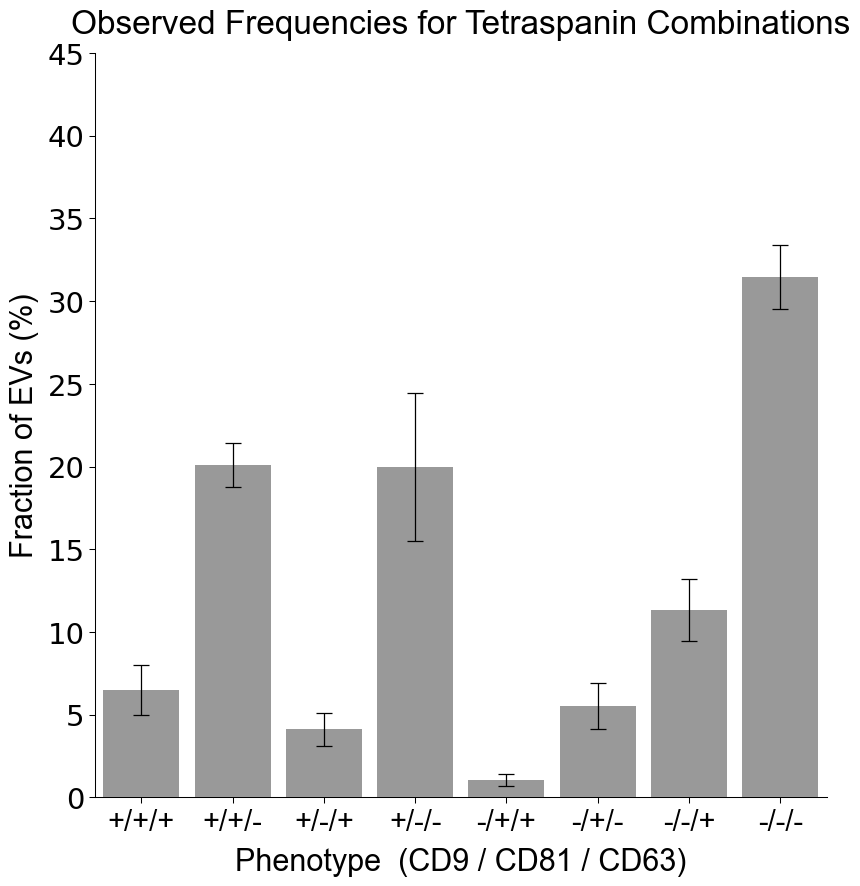

Cell 5 complete.


In [5]:
# ════════════════════════════════════════════════════════════════
# CELL 5 — Figure A: Observed data only
# ════════════════════════════════════════════════════════════════
_dbg('', cell_label='CELL 5 — Figure A (Observed only)')
_dbg(f'  obs_pct : {np.round(obs_pct,4).tolist()}')
_dbg(f'  obs_sd  : {np.round(obs_sd, 4).tolist()}')

FigureA_series = [
    {
        'label' : LEGEND_LABELS['Observed'],
        'key'   : 'Observed',
        'values': obs_pct,
        'errors': obs_sd,   # SD for observed
    }
]

make_grouped_bar_chart(
    CHART_TITLE_BASE, FigureA_series, FigureA_NAME,
    fig_width=FIG_WIDTH_FigureA,
    bar_width=BAR_WIDTH_FigureA,
    bar_gap=BAR_GAP_FigureA,
    group_gap=GROUP_GAP_FigureA,
    err_capsize=ERR_CAPSIZE_FigureA,
    show_legend=SHOW_LEGEND_FigureA,
)
_dbg('Cell 5 complete.')



------------------------------------------------------------------------
>>> CELL 6 — Figure D (All Models, SD error bars)
------------------------------------------------------------------------

  OPTION_ORDER : ['1B', '2B', '3B', '1A', '2A', '3A']
  GROUP_GAP_MULTI : 0.12
  Plotting "FigureF_All_Options_SD_20260610_141831"
    fig_width=14.0  FIG_HEIGHT=9.0  DPI=600
    n_series=7  n_groups=8
    _bw=0.1  _bg=0.01  _gg=0.12  _cap=2.5
    Y_MAX=45.0  FONT_FAMILY=Arial
    Series: ['Observed', 'Model 1B  (Linked, 1-class, k=5)', 'Model 2B  (Linked, 2-class, k=10)', 'Model 3B  (Linked, 3-class, k=15)', 'Model 1A  (Independent, 1-class, k=3)', 'Model 2A  (Independent, 2-class, k=7)', 'Model 3A  (Independent, 3-class, k=11)']
Saved PNG : C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureF_All_Options_SD_20260610_141831.png
    Saved PNG to: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Pro

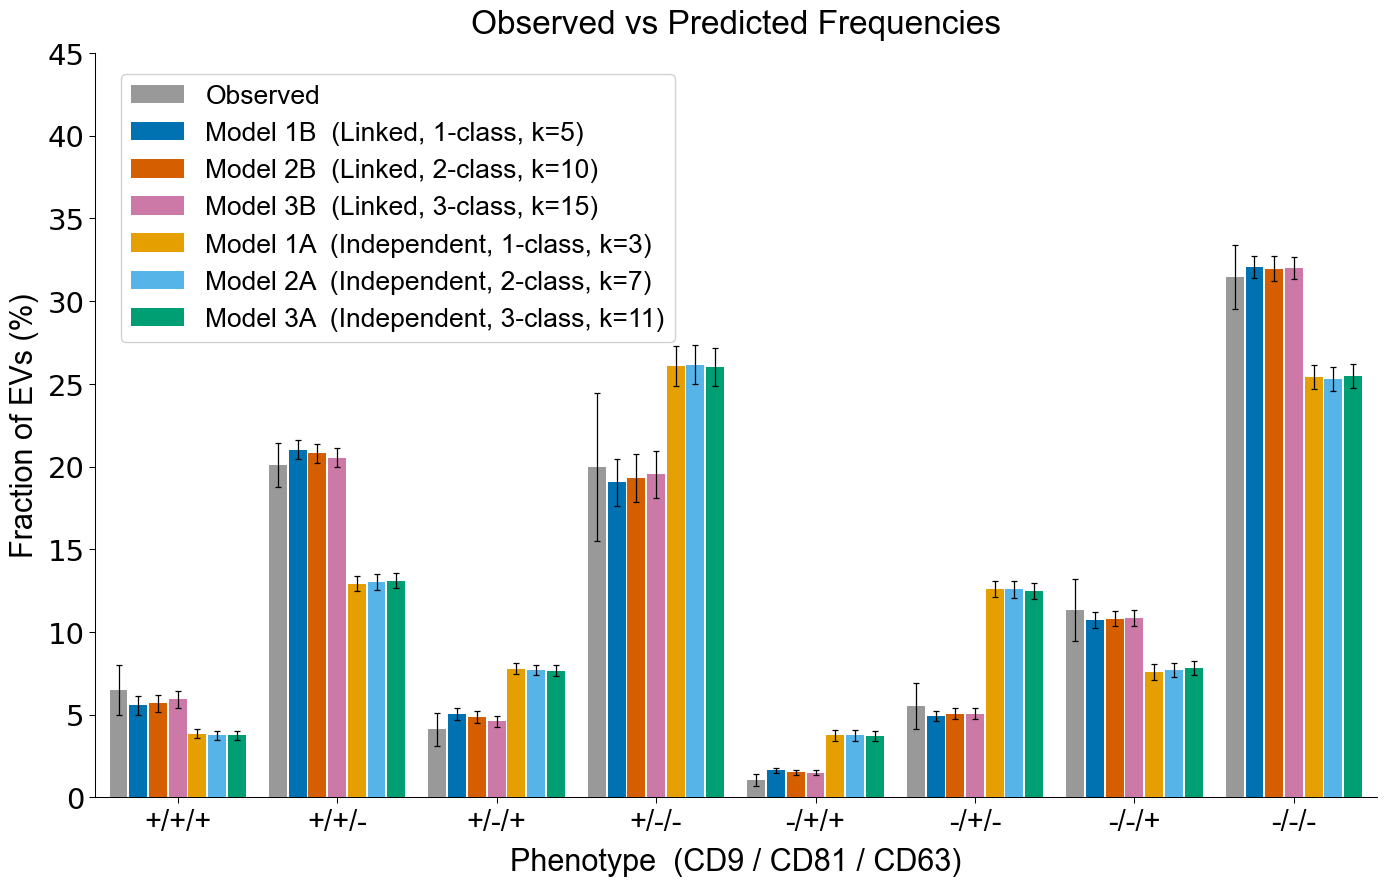

Cell 6 complete.


In [6]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — Figure D: Observed + all Models, SD error bars
# ════════════════════════════════════════════════════════════════
_dbg('', cell_label='CELL 6 — Figure D (All Models, SD error bars)')
_dbg(f'  OPTION_ORDER : {OPTION_ORDER}')
_dbg(f'  GROUP_GAP_MULTI : {GROUP_GAP_MULTI}')

chart2_series = [
    {
        'label' : LEGEND_LABELS['Observed'],
        'key'   : 'Observed',
        'values': obs_pct,
        'errors': obs_sd,
    }
]
for opt in OPTION_ORDER:
    chart2_series.append({
        'label' : LEGEND_LABELS[opt],
        'key'   : opt,
        'values': model_pred[opt],
        'errors': model_sd[opt],
    })

make_grouped_bar_chart(
    CHART_TITLE_PRED, chart2_series, CHART2_NAME,
    errbar_note_obs=ERRBAR_LABEL_OBS,
    errbar_note_pred=ERRBAR_LABEL_SD,
    group_gap=GROUP_GAP_MULTI,
)
_dbg('Cell 6 complete.')



------------------------------------------------------------------------
>>> CELL 7 — Chart 3 (DISABLED)
------------------------------------------------------------------------

Chart 3 disabled — skipping.
  GROUP_GAP_MULTI : 0.12
  Plotting "Chart3_All_Options_CI95_20260610_141831"
    fig_width=14.0  FIG_HEIGHT=9.0  DPI=600
    n_series=7  n_groups=8
    _bw=0.1  _bg=0.01  _gg=0.12  _cap=2.5
    Y_MAX=45.0  FONT_FAMILY=Arial
    Series: ['Observed', 'Model 1B  (Linked, 1-class, k=5)', 'Model 2B  (Linked, 2-class, k=10)', 'Model 3B  (Linked, 3-class, k=15)', 'Model 1A  (Independent, 1-class, k=3)', 'Model 2A  (Independent, 2-class, k=7)', 'Model 3A  (Independent, 3-class, k=11)']
Saved PNG : C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\Chart3_All_Options_CI95_20260610_141831.png
    Saved PNG to: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\

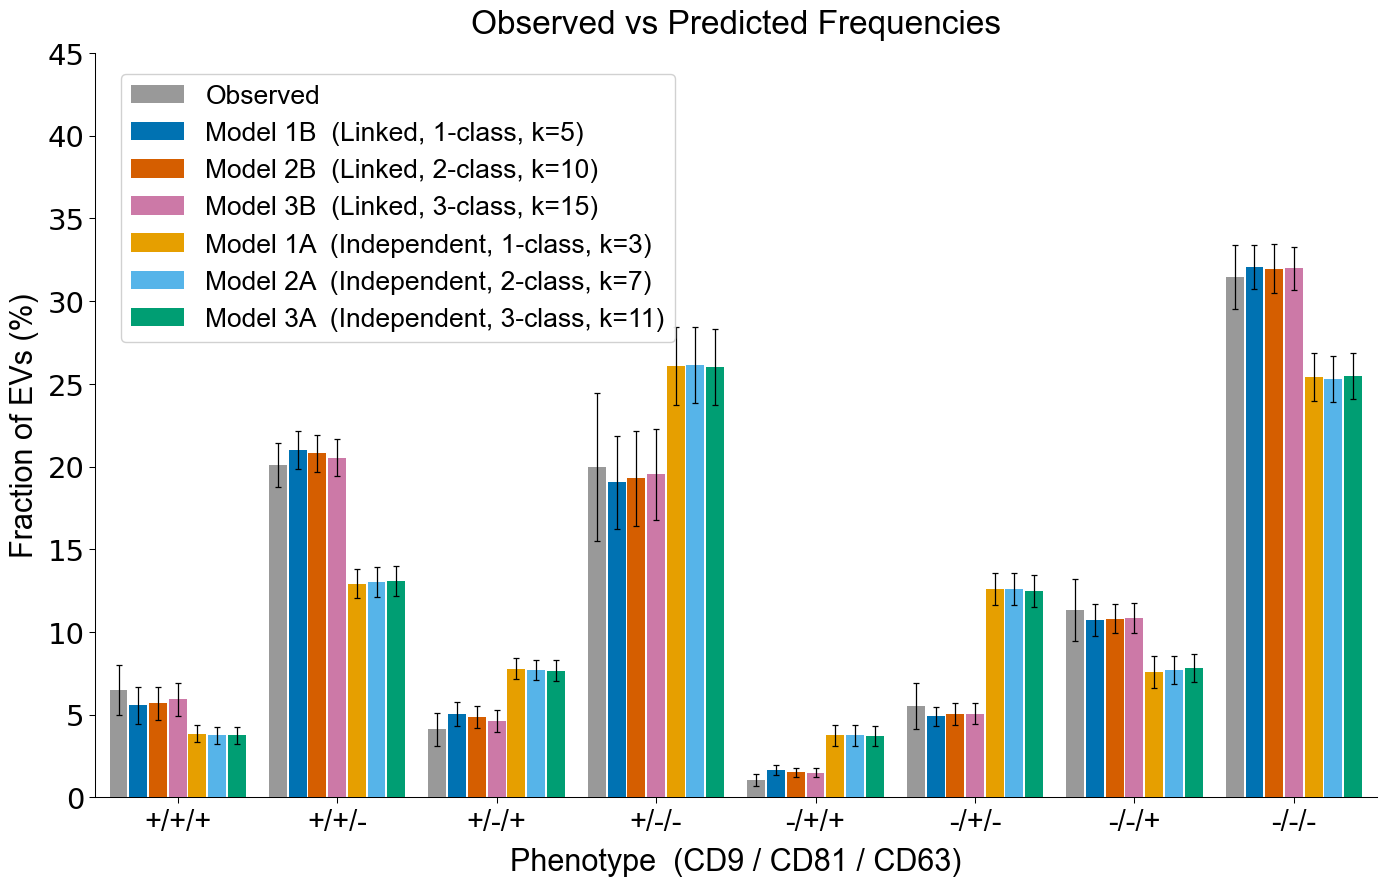

Cell 7 complete.

Debug log written to: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\debug\debug_20260610_141831.txt


In [7]:
# ════════════════════════════════════════════════════════════════
# CELL 7 — Chart 3: Observed + all Models, 95% CI error bars
# ════════════════════════════════════════════════════════════════
_dbg('', cell_label='CELL 7 — Chart 3 (DISABLED)')
print('Chart 3 disabled — skipping.')
if False:   # Chart 3 disabled
 _dbg(f'  OPTION_ORDER : {OPTION_ORDER}')
_dbg(f'  GROUP_GAP_MULTI : {GROUP_GAP_MULTI}')

chart3_series = [
    {
        'label' : LEGEND_LABELS['Observed'],
        'key'   : 'Observed',
        'values': obs_pct,
        'errors': obs_sd,            # SD for Observed in all charts
    }
]
for opt in OPTION_ORDER:
    chart3_series.append({
        'label' : LEGEND_LABELS[opt],
        'key'   : opt,
        'values': model_pred[opt],
        'errors': model_ci_hw[opt],   # 95% CI half-width from profile likelihood
    })

make_grouped_bar_chart(
    CHART_TITLE_PRED, chart3_series, CHART3_NAME,
    errbar_note_obs=ERRBAR_LABEL_OBS,
    errbar_note_pred=ERRBAR_LABEL_CI,
    group_gap=GROUP_GAP_MULTI,
)
_dbg('Cell 7 complete.')
print(f'\nDebug log written to: {DEBUG_LOG_PATH}')



------------------------------------------------------------------------
>>> CELL 8 — Figure E (D coefficient dot plot)
------------------------------------------------------------------------

Saved PNG : C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureE_D_Coefficients_20260610_141831.png
    Saved PNG to: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureE_D_Coefficients_20260610_141831.png
Saved PDF : C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureE_D_Coefficients_20260610_141831.pdf
    Saved PDF to: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureE_D_Coefficients_20260610_141831.pdf
Saved SVG : C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exo

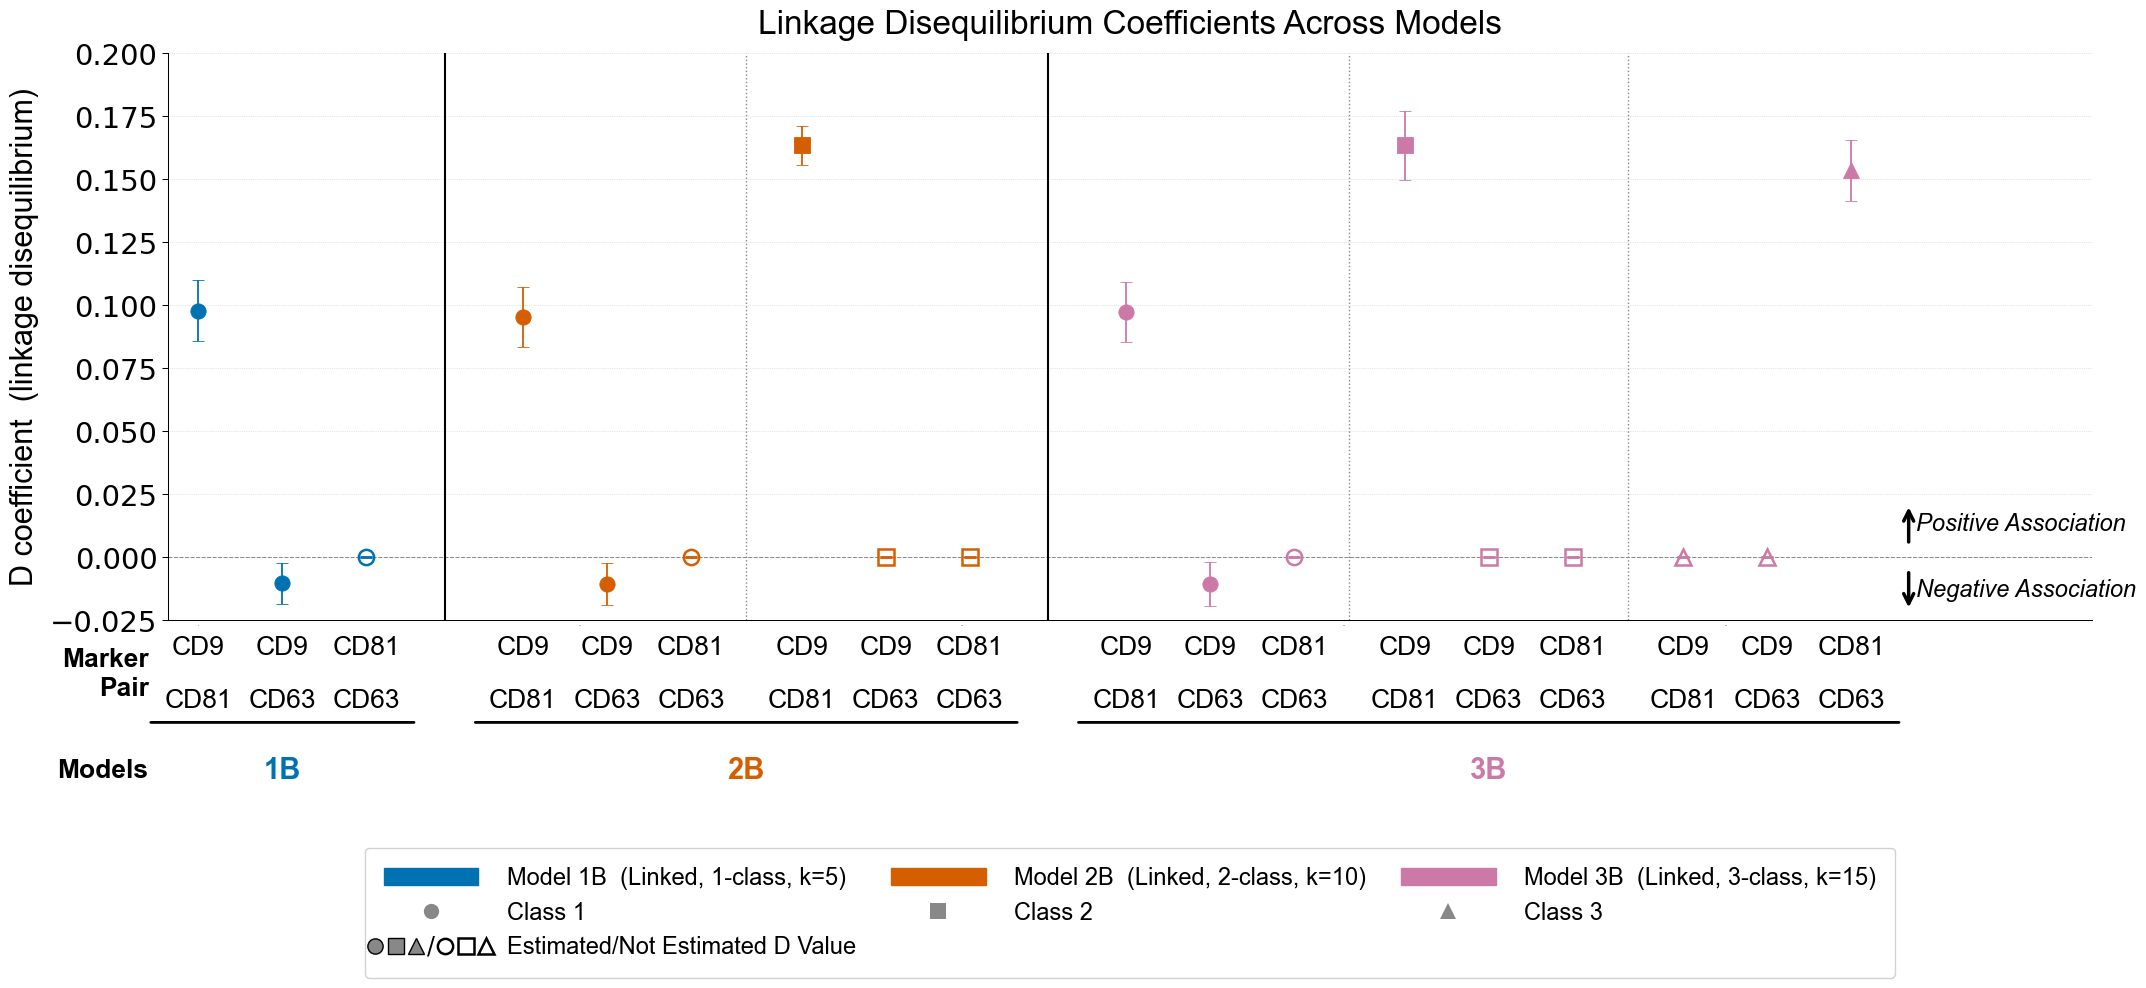

Cell 8 complete — Figure E done.

Debug log written to: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\debug\debug_20260610_141831.txt


In [8]:
# ════════════════════════════════════════════════════════════════
# CELL 8 — Figure E: D coefficient dot plot (Table S7L)
# Redesigned: X-axis = marker pairs, Y-axis = D coefficient
# Includes unlinked pairs at D=0 with open markers.
# ════════════════════════════════════════════════════════════════
_dbg('', cell_label='CELL 8 — Figure E (D coefficient dot plot)')

from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import matplotlib.transforms as mtransforms
import numpy as np

# ── Load Table S7L data ──────────────────────────────────────────
wb_l  = load_workbook(XLSX_PATH, data_only=True)
raw_l = list(wb_l[SHEET_NAME_L].iter_rows(values_only=True))
data_l = raw_l[DATA_START_L:DATA_END_L]

# Rows to suppress (boundary-saturated Pop C phi values)
D_CHART_EXCLUDE = {
    ('3B', 'CD9/CD81', 'Pop 3'),   # boundary saturation — excluded from base_rows; shown via UNLINKED as open marker
    ('3B', 'CD9/CD63', 'Pop 3'),   # boundary saturation — excluded from base_rows; shown via UNLINKED as open marker
}

# ── Build base data from Table S7L ──────────────────────────────
base_rows = [r for r in data_l
             if (r[COL_L_MODEL], r[COL_L_PAIR], r[COL_L_POP]) not in D_CHART_EXCLUDE]

d4_models = [r[COL_L_MODEL] for r in base_rows]
d4_pairs  = [r[COL_L_PAIR]  for r in base_rows]
d4_pops   = [r[COL_L_POP]   for r in base_rows]
d4_mle    = [float(str(r[COL_L_D_MLE]).replace('+',''))
             if r[COL_L_D_MLE] not in (None, '[0, 0]', '—') else 0.0
             for r in base_rows]
d4_sd     = [float(r[COL_L_SD]) if isinstance(r[COL_L_SD], (int, float)) else 0.0
             for r in base_rows]

# ── Define all possible pairs and which are "unlinked by definition" ──
# All three pairs that exist in the data
ALL_PAIRS  = ['CD9/CD81', 'CD9/CD63', 'CD81/CD63']

# Pairs that are structurally zero (not fitted) — shown as open markers at D=0
# CD81/CD63 not fitted in 1B or 2B (chi-sq independence); shown as open
UNLINKED = {
    ('1B', 'CD81/CD63', 'Pop 1'),   # not fitted — chi-sq independence
    ('2B', 'CD9/CD63',  'Pop 2'),   # not in table — set D=0
    ('2B', 'CD81/CD63', 'Pop 1'),   # not fitted — chi-sq independence
    ('2B', 'CD81/CD63', 'Pop 2'),   # not fitted — chi-sq independence
    ('3B', 'CD9/CD63',  'Pop 2'),   # not in table — set D=0
    ('3B', 'CD9/CD81',  'Pop 3'),   # boundary saturation — D forced to 0
    ('3B', 'CD9/CD63',  'Pop 3'),   # boundary saturation — D forced to 0
    ('3B', 'CD81/CD63', 'Pop 1'),   # not fitted — chi-sq independence
    ('3B', 'CD81/CD63', 'Pop 2'),   # not fitted — chi-sq independence
}

# Build complete set of points: linked (filled) + unlinked (open, D=0)
# Each point is (model, pair, pop, D_mle, D_sd, is_open)
all_points = []
# Filled points from table
for model, pair, pop, mle, sd in zip(d4_models, d4_pairs, d4_pops, d4_mle, d4_sd):
    all_points.append((model, pair, pop, mle, sd, False))

# Open (unlinked) points at D=0
for model, pair, pop in UNLINKED:
    all_points.append((model, pair, pop, 0.0, 0.0, True))

# ── Assign x positions ──────────────────────────────────────────
# Group models: 1B (left cluster), 2B (middle), 3B (right)
# Within each model, order by pair: CD9/CD81, CD9/CD63, CD81/CD63
# Within each pair within model, order by population

MODEL_ORDER  = ['1B', '2B', '3B']
PAIR_ORDER   = ['CD9/CD81', 'CD9/CD63', 'CD81/CD63']
POP_ORDER    = ['Pop 1', 'Pop 2', 'Pop 3']
MODEL_GROUP_GAP = 3.0   # extra gap between model groups
PAIR_GAP        = 1.8   # gap between pairs within a model
POP_SPACING     = 1.1   # spacing between pops within a pair/model

# Which pops exist per model
MODEL_POPS = {'1B': ['Pop 1'], '2B': ['Pop 1', 'Pop 2'], '3B': ['Pop 1', 'Pop 2', 'Pop 3']}

# Sort: model → pop → pair  (so each pop's 3 pairs stay together)
def sort_key(pt):
    model, pair, pop = pt[0], pt[1], pt[2]
    mi = MODEL_ORDER.index(model) if model in MODEL_ORDER else 99
    oi = POP_ORDER.index(pop)     if pop   in POP_ORDER   else 99
    pi = PAIR_ORDER.index(pair)   if pair  in PAIR_ORDER  else 99
    return (mi, oi, pi)

all_points.sort(key=sort_key)

# Assign x coordinate
x_pos = []
x_val = 0.0
prev_model = None
prev_pair  = None
for pt in all_points:
    model, pair = pt[0], pt[1]
    if prev_model is None:
        pass
    elif model != prev_model:
        x_val += MODEL_GROUP_GAP
    elif pair != prev_pair:
        x_val += PAIR_GAP
    else:
        x_val += POP_SPACING
    x_pos.append(x_val)
    prev_model = model
    prev_pair  = pair
    x_val += POP_SPACING if prev_pair == pair else 0

# Re-assign: gap on model change, pair gap on pop change, POP_SPACING between pairs
x_pos = []
x_val = 0.0
prev_model = None; prev_pop = None; prev_pair = None
for i, pt in enumerate(all_points):
    model, pair, pop = pt[0], pt[1], pt[2]
    if i == 0:
        pass
    elif model != prev_model:
        x_val += MODEL_GROUP_GAP
    elif pop != prev_pop:
        x_val += PAIR_GAP
    else:
        x_val += POP_SPACING
    x_pos.append(x_val)
    x_val += POP_SPACING
    prev_model = model; prev_pop = pop; prev_pair = pair

# Also build model-level x ranges for bracket lines
from collections import defaultdict as _dd
_model_xs = _dd(list)
for pt, xp in zip(all_points, x_pos):
    _model_xs[pt[0]].append(xp)

x_arr = np.array(x_pos)

# ── Compute group midpoints for x-axis labels ────────────────────
from collections import defaultdict
# Per (model, pop) group midpoints — for pair label x positions
pop_grp_x = defaultdict(list)
for pt, xp in zip(all_points, x_arr):
    pop_grp_x[(pt[0], pt[2])].append(xp)   # (model, pop) → [xpos of its 3 pairs]

# Per individual (model, pop, pair) x position — used for pair labels
indiv_x = {}
for pt, xp in zip(all_points, x_arr):
    indiv_x[(pt[0], pt[2], pt[1])] = xp    # (model, pop, pair) → xpos

# Model group midpoints and extents
model_x = defaultdict(list)
for pt, xp in zip(all_points, x_arr):
    model_x[pt[0]].append(xp)
model_midpoints = {k: np.mean(v) for k, v in model_x.items()}
model_extents   = {k: (min(v), max(v)) for k, v in model_x.items()}

# ── Draw chart ───────────────────────────────────────────────────
FIG_WIDTH_E  = 26.0
FIG_HEIGHT_E =  9.0
fig, ax = plt.subplots(figsize=(FIG_WIDTH_E, FIG_HEIGHT_E))
fig.subplots_adjust(bottom=0.25, top=0.88, left=0.06, right=0.80)

# Reference line at D = 0
ax.axhline(0, color='black', linewidth=D_CHART_REFLINE_WIDTH,
           linestyle='--', zorder=1, alpha=D_CHART_REFLINE_ALPHA)

# Directional arrows — placed at right of chart, close to zero line
_xlim_l = x_arr.min() - 0.8
_xlim_r = x_arr.max() + 0.8
_arr_x   = x_arr.max() + 1.5   # well right of all marker pair labels
_arr_dy  = 0.005   # close to zero line
_arr_len = 0.016   # arrow length

for _sign, _label, _va in [(+1, 'Positive Association', 'bottom'),
                             (-1, 'Negative Association', 'top')]:
    # Arrow: tail at zero side, head at far end
    ax.annotate('', xy=(_arr_x, _sign * (_arr_dy + _arr_len)),
                xytext=(_arr_x, _sign * _arr_dy),
                arrowprops=dict(arrowstyle='->', color='black',
                                lw=2.5, mutation_scale=18))
    ax.text(_arr_x + 0.2, _sign * (_arr_dy + _arr_len / 2),
            _label, ha='left', va='center',
            fontsize=FONT_SIZE_TICK_C4 - 4, fontfamily=FONT_FAMILY,
            color='black', style='italic')

# Plot each point
_chart_ms = D_CHART_MARKERSIZE + 2   # 2pt larger in chart vs legend

for pt, xp in zip(all_points, x_arr):
    model, pair, pop, mle, sd, is_open = pt
    color  = COLOR_MAP[model]
    marker = POP_MARKER.get(pop, 'o')
    if is_open:
        # Open/outline marker: unfilled with coloured edge
        ax.errorbar(xp, mle, yerr=sd,
                    fmt=marker, color='none',
                    markeredgecolor=color,
                    markeredgewidth=1.8,
                    markersize=_chart_ms,
                    elinewidth=D_CHART_ERR_LINEWIDTH,
                    capsize=D_CHART_ERR_CAPSIZE,
                    capthick=D_CHART_ERR_CAPTHICK,
                    ecolor=color, zorder=3)
    else:
        ax.errorbar(xp, mle, yerr=sd,
                    fmt=marker, color=color,
                    markersize=_chart_ms,
                    markeredgewidth=D_CHART_MARKER_EDGEWIDTH,
                    markeredgecolor=color,
                    elinewidth=D_CHART_ERR_LINEWIDTH,
                    capsize=D_CHART_ERR_CAPSIZE,
                    capthick=D_CHART_ERR_CAPTHICK,
                    ecolor=color, zorder=3)

# ── Axes style ───────────────────────────────────────────────────
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_linewidth(SPINE_LINEWIDTH)
ax.spines['bottom'].set_linewidth(SPINE_LINEWIDTH)
ax.tick_params(axis='y', length=TICK_LENGTH, width=TICK_WIDTH, direction='out',
               labelsize=FONT_SIZE_TICK_C4)
ax.tick_params(axis='x', length=0, labelsize=0)   # x ticks hidden — custom labels below
ax.set_xlim(_xlim_l, _xlim_r + 5.5)   # extend right for arrow labels
ax.set_ylim(-0.025, 0.20)
ax.grid(axis='y', linestyle=':', linewidth=D_CHART_GRID_LINEWIDTH,
        alpha=D_CHART_GRID_ALPHA, color=D_CHART_GRID_COLOR)
ax.set_ylabel(D_CHART_XLABEL,   # reuse D_CHART_XLABEL as y-axis label
              fontname=FONT_FAMILY, fontsize=FONT_SIZE_AXIS_C4, labelpad=XLABEL_LABELPAD)

# ── Model bracket lines — below pair labels, above model name labels ──
_bkt_y   = -0.18   # axes-fraction: below the pair labels
_bkt_lw  = 2.0
_bkt_trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
for model, (x_lo, x_hi) in model_extents.items():
    pad = POP_SPACING * 1.2   # wider pad to cover text label width
    ax.annotate('', xy=(x_hi + pad, _bkt_y), xytext=(x_lo - pad, _bkt_y),
                xycoords=_bkt_trans, textcoords=_bkt_trans,
                arrowprops=dict(arrowstyle='-', color='black', lw=_bkt_lw),
                annotation_clip=False)

# ── Vertical separator lines ──────────────────────────────────────
# Solid black between models, dotted between populations within a model
_sep_ymin = 0.0    # bottom of y-axis (D=0 line)
_sep_ymax = 0.20   # top of plot area

# Build per-group x ranges: track LAST xp of each (model, pop) group
from collections import defaultdict as _dd2
_grp_last  = {}   # (model, pop) → last xp in that group
_grp_first = {}   # (model, pop) → first xp in that group
for pt, xp in zip(all_points, x_arr):
    key = (pt[0], pt[2])
    if key not in _grp_first:
        _grp_first[key] = xp
    _grp_last[key] = xp

# Ordered group list by first xp
_grp_order = sorted(_grp_first.keys(), key=lambda k: _grp_first[k])

# Draw separator at midpoint between last-of-prev and first-of-next
for idx in range(1, len(_grp_order)):
    prev_key = _grp_order[idx - 1]
    curr_key = _grp_order[idx]
    sep_x = (_grp_last[prev_key] + _grp_first[curr_key]) / 2
    if prev_key[0] != curr_key[0]:
        # Solid black line between models
        ax.axvline(sep_x, ymin=0, ymax=1, color='black',
                   linewidth=1.5, linestyle='-', zorder=2)
    else:
        # Dotted grey line between populations within same model
        ax.axvline(sep_x, ymin=0, ymax=1, color='#888888',
                   linewidth=1.0, linestyle=':', zorder=2)

# ── Custom x-axis: pair labels and model labels ───────────────────
_label_y_top    = -0.07   # axes-fraction: upper tetraspanin name
_label_y_bottom = -0.12   # axes-fraction: lower tetraspanin name
_bkt_y          = -0.18   # already set above — bracket line
_model_y        = -0.24   # axes-fraction: model name below bracket
_models_hdr_y   = -0.30   # axes-fraction: "Models" label

_trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

for pt, xp in zip(all_points, x_arr):
    pair = pt[1]
    parts = pair.split('/')
    ax.text(xp, _label_y_top, parts[0],
            transform=_trans, ha='center', va='bottom',
            fontsize=FONT_SIZE_TICK_C4 - 2, fontfamily=FONT_FAMILY, color='black')
    ax.text(xp, _label_y_bottom, parts[1] if len(parts) > 1 else '',
            transform=_trans, ha='center', va='top',
            fontsize=FONT_SIZE_TICK_C4 - 2, fontfamily=FONT_FAMILY, color='black')

# "Marker Pair" label — left of figure, vertically centred on pair labels
_mp_centre_y = (_label_y_top + _label_y_bottom) / 2
ax.text(-0.01, _mp_centre_y, 'Marker\nPair',
        transform=ax.transAxes, ha='right', va='center',
        fontsize=FONT_SIZE_TICK_C4 - 2, fontfamily=FONT_FAMILY,
        fontweight='bold', color='black', linespacing=1.3)

# Model name labels — centred on bracket midpoint in data coords
_xlim_total_r = _xlim_r + 5.5   # must match ax.set_xlim extension
for model, (x_lo, x_hi) in model_extents.items():
    bkt_mid = (x_lo + x_hi) / 2
    _norm_x = (bkt_mid - _xlim_l) / (_xlim_total_r - _xlim_l)
    ax.text(_norm_x, _model_y, model,
            transform=ax.transAxes, ha='center', va='top',
            fontsize=FONT_SIZE_TICK_C4, fontfamily=FONT_FAMILY,
            fontweight='bold', color=COLOR_MAP[model])

# "Models" header label — left of figure, vertically centred on model name labels
# Model names use va='top' at _model_y, so their visual centre is slightly below
ax.text(-0.01, _model_y - 0.025, 'Models',
        transform=ax.transAxes, ha='right', va='center',
        fontsize=FONT_SIZE_TICK_C4 - 2, fontfamily=FONT_FAMILY,
        fontweight='bold', color='black')

ax.set_title(CHART4_TITLE, fontname=FONT_FAMILY,
             fontsize=FONT_SIZE_TITLE_C4, pad=TITLE_PAD, fontweight='normal')

# ── Legend — two separate columns: Pop 1/2/3 left, D=0 right ─────
# Use a two-column layout with model colour patches in col 1 rows 1-3,
# Legend: Col 1 = Model colours, Col 2 = Pop markers, Col 3 = Estimated/Not Estimated
# The estimated/not-estimated entry uses a custom handler to show filled+open side by side.
# Simplest approach: one entry per pop showing filled marker / open marker + label.
_spacer = mpatches.Patch(color='none', label='')

class _MultiSplitMarker:
    """Legend handle: three filled shapes, '/', three open shapes with spacing."""
    def __init__(self, color, edge, ms):
        self.color = color; self.edge = edge; self.ms = ms

class _MultiSplitMarkerHandler:
    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        import matplotlib.lines as _ml
        x0, y0 = handlebox.xdescent, handlebox.ydescent
        w, h   = handlebox.width, handlebox.height
        ms = orig_handle.ms
        fc = orig_handle.color
        ec = 'black'   # solid black outline on all markers
        shapes = ['o', 's', '^']
        # Layout: 3 filled widely spaced, slash, 3 open widely spaced
        # Use absolute point spacing based on marker size rather than
        # dividing the handlebox width (which is too narrow for 6 markers)
        spacing   = ms * 1.25 + 1   # 3.2 preserves ~3pt visual gap between marker edges regardless of ms size
        slash_gap = ms * 0.95 + 0   # 1.05 1.25 3.2 same for slash gap
        # Total width of the 6 markers + slash group
        total_w = spacing * 2 + slash_gap * 2 + spacing * 2   # 3 filled + gap + slash + gap + 3 open
        # Centre the whole group on the horizontal midpoint of the handlebox
        handle_pts = w   # handlebox width in points
        centre_x = x0 + handle_pts / 2
        group_start = centre_x - total_w / 2
        xs_filled = [group_start + spacing * i for i in range(3)]
        slash_x   = xs_filled[-1] + slash_gap
        xs_open   = [slash_x + slash_gap + spacing * i for i in range(3)]
        cy = y0 + h / 2
        # Three filled markers
        for xi, shape in zip(xs_filled, shapes):
            m = _ml.Line2D([xi], [cy], marker=shape, color=fc,
                           markeredgecolor=ec, markeredgewidth=1.0,
                           markersize=ms, linestyle='None',
                           transform=handlebox.get_transform())
            handlebox.add_artist(m)
        # Slash separator
        slash = plt.Text(slash_x, cy, '/',
                         ha='center', va='center',
                         fontsize=fontsize * 1.0,
                         transform=handlebox.get_transform())
        handlebox.add_artist(slash)
        # Three open markers with black outline
        for xi, shape in zip(xs_open, shapes):
            m = _ml.Line2D([xi], [cy], marker=shape, color='none',
                           markeredgecolor=ec, markeredgewidth=1.8,
                           markersize=ms, linestyle='None',
                           transform=handlebox.get_transform())
            handlebox.add_artist(m)
        return _ml.Line2D([x0], [cy], linestyle='None',
                          transform=handlebox.get_transform())

_ms = D_CHART_LEGEND_MARKERSIZE
_ec = 'black'                          # outline for open markers in multi-split
_fc = D_CHART_LEGEND_MARKER_COLOR      # grey fill for pop markers
_pop_ec = 'none'                       # no outline on solid grey pop markers

_multi_split = _MultiSplitMarker(_fc, _ec, _ms)

_legend_handles = [
    # Col 1: Model colour patches
    mpatches.Patch(color=COLOR_MAP['1B'], label=LEGEND_LABELS['1B']),
    # Col 2: Pop marker + name
Line2D([0],[0], marker='o', color=_fc, markeredgecolor=_pop_ec,
           markeredgewidth=0.0, markersize=_ms, linestyle='None', label='Class 1'),
    # Col 3: Multi-marker estimated/not-estimated entry
    _multi_split,
    mpatches.Patch(color=COLOR_MAP['2B'], label=LEGEND_LABELS['2B']),
    Line2D([0],[0], marker='s', color=_fc, markeredgecolor=_pop_ec,
           markeredgewidth=0.0, markersize=_ms, linestyle='None', label='Class 2'),
    _spacer,
    mpatches.Patch(color=COLOR_MAP['3B'], label=LEGEND_LABELS['3B']),
    Line2D([0],[0], marker='^', color=_fc, markeredgecolor=_pop_ec,
           markeredgewidth=0.0, markersize=_ms, linestyle='None', label='Class 3'),
    _spacer,
]

_handler_map = {_multi_split: _MultiSplitMarkerHandler()}
ax.legend(
    handles=_legend_handles,
    handler_map=_handler_map,
    labels=[LEGEND_LABELS['1B'], 'Class 1', 'Estimated/Not Estimated D Value',
            LEGEND_LABELS['2B'], 'Class 2', '',
            LEGEND_LABELS['3B'], 'Class 3', ''],
    loc='upper center',
    bbox_to_anchor=(0.5, -0.38),
    ncol=3,
    fontsize=FONT_SIZE_LEGEND_CHART4,
    frameon=True,
    framealpha=LEGEND_FRAMEALPHA,
    edgecolor=LEGEND_EDGECOLOR,
    prop={'family': FONT_FAMILY, 'size': FONT_SIZE_LEGEND_CHART4},
    handlelength=4.0,        # wide enough to hold 6 markers + slash without text overlap
    handletextpad=1.2,       # gap between handle and label text
    columnspacing=D_CHART_LEGEND_COLSPACING,
    borderpad=0.8,
)

fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ── Save ─────────────────────────────────────────────────────────
for _fmt in SAVE_FORMATS:
    _out = os.path.join(OUTPUT_DIR, f'{CHART4_NAME}.{_fmt}')
    _kw  = {'bbox_inches': 'tight', 'facecolor': 'white'}
    if _fmt == 'png':
        _kw['dpi'] = DPI
    plt.savefig(_out, **_kw)
    print(f'Saved {_fmt.upper():4s}: {_out}')
    _dbg(f'    Saved {_fmt.upper()} to: {_out}')

plt.show()
plt.close()

_dbg('Cell 8 complete — Figure E done.')
print(f'\nDebug log written to: {DEBUG_LOG_PATH}')



------------------------------------------------------------------------
>>> CELL 9 — Figures B/C/D (Copy Number distributions)
------------------------------------------------------------------------

  CD9: 19 CN values, non-zero=9
Saved PNG : C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureB_CD9_CopyNumber_20260610_141831.png
    Saved PNG to: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureB_CD9_CopyNumber_20260610_141831.png
Saved PDF : C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureB_CD9_CopyNumber_20260610_141831.pdf
    Saved PDF to: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureB_CD9_CopyNumber_20260610_141831.pdf
Saved SVG : C:\Users\pdeho\OneDrive - University of C

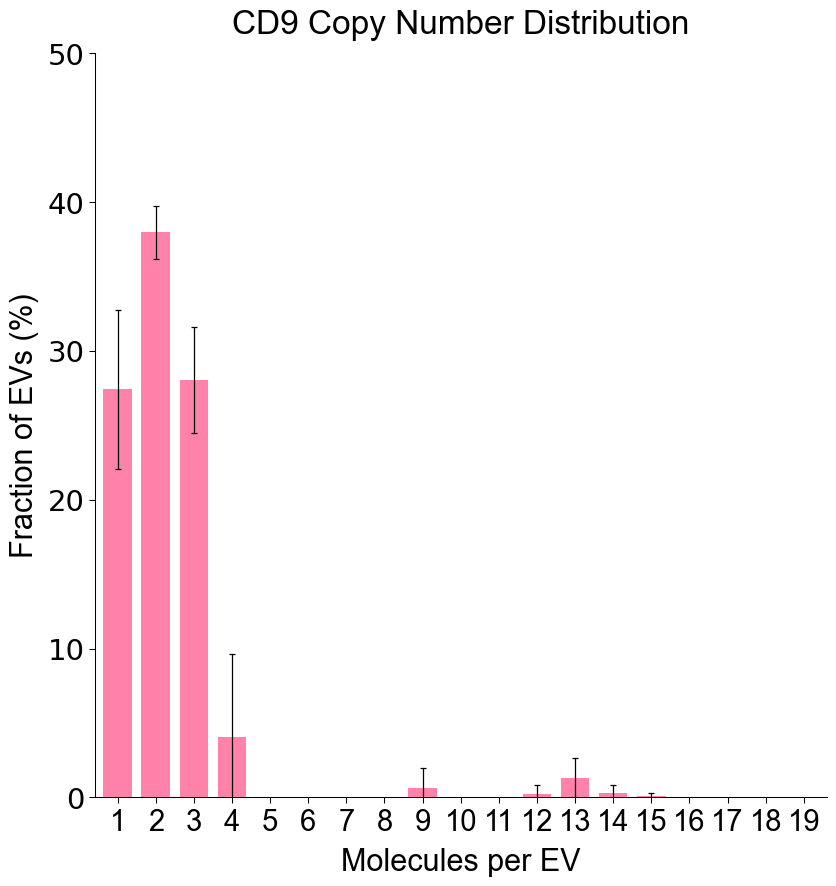

  CD81: 19 CN values, non-zero=5
Saved PNG : C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureC_CD81_CopyNumber_20260610_141831.png
    Saved PNG to: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureC_CD81_CopyNumber_20260610_141831.png
Saved PDF : C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureC_CD81_CopyNumber_20260610_141831.pdf
    Saved PDF to: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureC_CD81_CopyNumber_20260610_141831.pdf
Saved SVG : C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureC_CD81_CopyNumber_20260610_141831.svg
    Saved SVG to: C:\Users\pdeho\OneDrive - University of California, San D

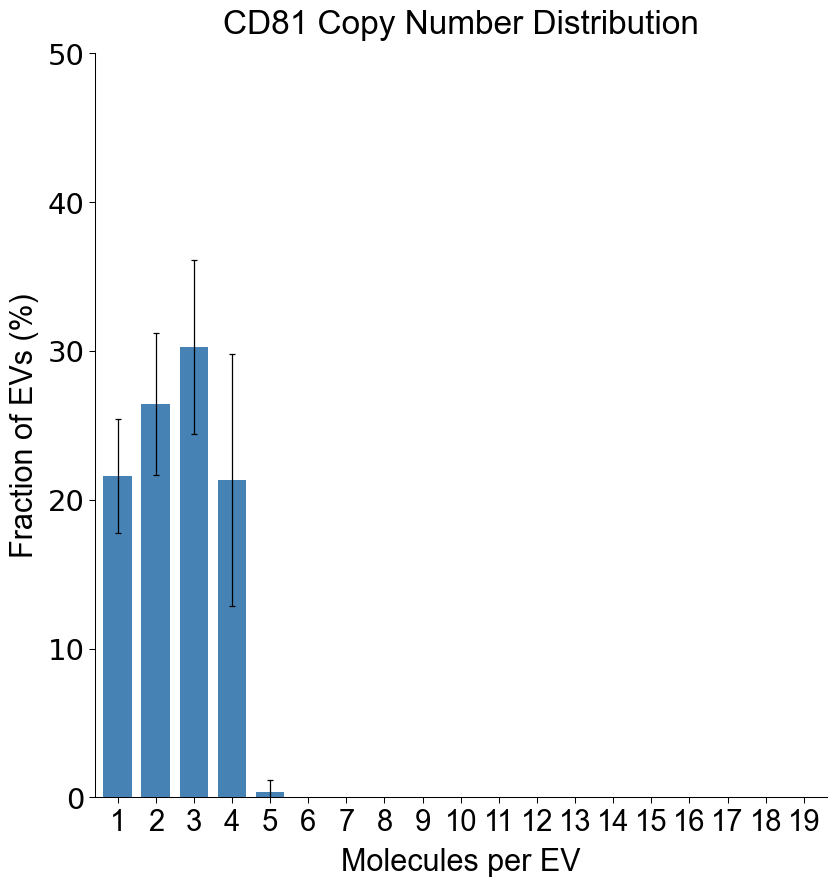

  CD63: 19 CN values, non-zero=5
Saved PNG : C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureD_CD63_CopyNumber_20260610_141831.png
    Saved PNG to: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureD_CD63_CopyNumber_20260610_141831.png
Saved PDF : C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureD_CD63_CopyNumber_20260610_141831.pdf
    Saved PDF to: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureD_CD63_CopyNumber_20260610_141831.pdf
Saved SVG : C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\FigureD_CD63_CopyNumber_20260610_141831.svg
    Saved SVG to: C:\Users\pdeho\OneDrive - University of California, San D

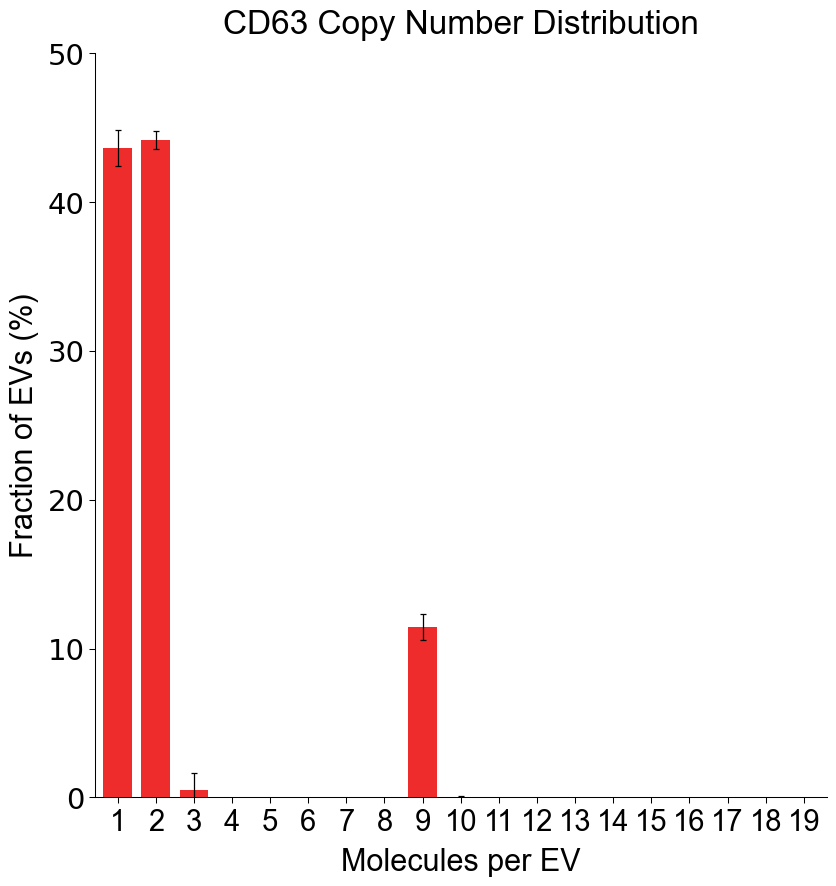

Cell 9 complete — Figures B/C/D done.

All Figures B/C/D outputs complete. Debug: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\debug\debug_20260610_141831.txt


In [9]:
# ════════════════════════════════════════════════════════════════
# CELL 9 — Figures B, C, D: Copy Number distributions (Table S7B)
# ════════════════════════════════════════════════════════════════
_dbg('', cell_label='CELL 9 — Figures B/C/D (Copy Number distributions)')

wb_b   = load_workbook(XLSX_PATH, data_only=True)
raw_b  = list(wb_b[SHEET_NAME_B].iter_rows(values_only=True))
data_b = raw_b[TABLE_B_DATA_START:TABLE_B_DATA_END]

for chart_idx, (marker, col_start, chart_title) in enumerate(TABLE_B_MARKERS):

    cn_labels = []; b5_means = []; b5_sds = []
    for row in data_b:
        cn = row[col_start + TABLE_B_COL_CN]
        try:
            cn = float(cn)
        except (TypeError, ValueError):
            continue
        reps  = [row[col_start + j] for j in range(TABLE_B_COL_R1, TABLE_B_COL_R5 + 1)]
        valid = [v for v in reps if v is not None and isinstance(v, (int, float))]
        mean  = float(np.mean(valid))       if valid       else 0.0
        sd    = float(np.std(valid, ddof=1)) if len(valid)>1 else 0.0
        cn_labels.append(int(cn)); b5_means.append(mean); b5_sds.append(sd)

    cn_arr = np.array(cn_labels)
    mean_arr = np.array(b5_means)
    sd_arr   = np.array(b5_sds)
    _dbg(f'  {marker}: {len(cn_arr)} CN values, non-zero={sum(mean_arr>0.01)}')

    fig, ax = plt.subplots(figsize=(FIG_WIDTH_FigureA, FIG_HEIGHT))
    x = np.arange(len(cn_arr))
    ax.bar(x, mean_arr, width=FigureB_BAR_WIDTH,
           color=FigureB_BAR_COLOR[marker], edgecolor='none', linewidth=0, zorder=3)
    # Only draw error bars for rows where the mean is non-zero
    # Zero-mean rows produce a visible cap line on the x-axis even with SD=0
    _nonzero = mean_arr > 0
    if _nonzero.any():
        ax.errorbar(x[_nonzero], mean_arr[_nonzero], yerr=sd_arr[_nonzero],
                    fmt='none', ecolor='black',
                    elinewidth=ERR_LINEWIDTH, capsize=FigureB_ERR_CAPSIZE,
                    capthick=ERR_CAPTHICK, zorder=4)

    for spine in ['top','right']: ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(SPINE_LINEWIDTH)
    ax.spines['bottom'].set_linewidth(SPINE_LINEWIDTH)
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in cn_labels],
                       fontname=FONT_FAMILY, fontsize=FONT_SIZE_TICK_X_C5)
    ax.tick_params(axis='x', length=TICK_LENGTH, width=TICK_WIDTH, direction='out')
    ax.tick_params(axis='y', length=TICK_LENGTH, width=TICK_WIDTH,
                   direction='out', labelsize=FONT_SIZE_TICK_C5)
    ax.grid(False)
    # Unified Y-axis for all Figure B panels; topmost tick crosses the spine
    ax.set_ylim(0, FigureB_Y_MAX)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.set_xlim(-0.6, len(cn_arr) - 0.4)
    ax.set_xlabel(FigureB_XLABEL, fontname=FONT_FAMILY,
                  fontsize=FONT_SIZE_AXIS_C5, labelpad=XLABEL_LABELPAD)
    ax.set_ylabel(FigureB_YLABEL, fontname=FONT_FAMILY,
                  fontsize=FONT_SIZE_AXIS_C5, labelpad=YLABEL_LABELPAD)
    ax.set_title(chart_title, fontname=FONT_FAMILY,
                 fontsize=FONT_SIZE_TITLE_C5, pad=TITLE_PAD, fontweight='normal')
    fig.patch.set_facecolor('white'); ax.set_facecolor('white')
    plt.tight_layout(pad=TIGHT_LAYOUT_PAD)

    for _fmt in SAVE_FORMATS:
        _out = os.path.join(OUTPUT_DIR, f'{FigureB_NAMES[chart_idx]}.{_fmt}')
        _kw  = {'bbox_inches': 'tight', 'facecolor': 'white'}
        if _fmt == 'png': _kw['dpi'] = DPI
        plt.savefig(_out, **_kw)
        print(f'Saved {_fmt.upper():4s}: {_out}')
        _dbg(f'    Saved {_fmt.upper()} to: {_out}')

    plt.show()
    plt.close()

_dbg('Cell 9 complete — Figures B/C/D done.')
print(f'\nAll Figures B/C/D outputs complete. Debug: {DEBUG_LOG_PATH}')


In [10]:
# ════════════════════════════════════════════════════════════════
# CELL 11 — Publication Tables  (all 12 tabs → PNG + SVG + combined PDF)
# Output: Tables/ subfolder alongside the XLSX file
# ════════════════════════════════════════════════════════════════
from reportlab.lib.pagesizes import A3, landscape
from reportlab.platypus import (SimpleDocTemplate, Table, TableStyle,
    Paragraph, Spacer, PageBreak)
from reportlab.lib.styles import ParagraphStyle
from reportlab.lib import colors as rl_colors
from reportlab.lib.units import inch
import matplotlib.patches as mpatches

import os, sys, numpy as np, textwrap
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from openpyxl import load_workbook
from reportlab.lib.pagesizes import A3, A4, landscape, portrait
from reportlab.platypus import (SimpleDocTemplate, Table, TableStyle,
    Paragraph, Spacer, PageBreak, KeepTogether)
from reportlab.lib.styles import ParagraphStyle
from reportlab.lib import colors as rl_colors
from reportlab.lib.units import inch, cm

# ── Constants ─────────────────────────────────────────────────
FONT   = 'Helvetica'
FONT_B = 'Helvetica-Bold'
FONT_I = 'Helvetica-Oblique'
FS     = 9      # body font size (pt)
FS_HDR = 9      # header font size
FS_TTL = 12     # title font size
FS_FT  = 7      # footnote font size
DPI    = 300
#plt.rcParams['font.family'] = [FONT_FAMILY, 'Arial Unicode MS', 'Segoe UI', 'DejaVu Sans']
plt.rcParams['font.family'] = FONT_FAMILY_LIST

# Colorblind-safe palette  ─ Wong 2011
C_BLUE_L   = (0.84, 0.91, 0.98)   # 1B rows
C_GREEN_L  = (0.91, 0.96, 0.91)   # 2B rows
C_ORANGE_L = (0.99, 0.95, 0.88)   # 3B / orange rows
C_GOLD_L   = (1.00, 0.97, 0.85)   # AIC-best (3B alt)
C_GREY_H   = (0.18, 0.18, 0.18)   # dark header
C_GREY_SH  = (0.40, 0.40, 0.40)   # sub-header
C_GREY_R   = (0.95, 0.95, 0.95)   # alternating row
C_WHITE    = (1.00, 1.00, 1.00)
C_RED_L    = (0.99, 0.88, 0.88)   # excluded / rejected

def rgb(r,g,b): return rl_colors.Color(r,g,b)

OUT = os.path.join(os.path.dirname(XLSX_PATH), 'Tables')
os.makedirs(OUT, exist_ok=True)

wb = load_workbook(XLSX_PATH, data_only=True)

# ── Paragraph styles ──────────────────────────────────────────
def S(name, **kw):
    defaults = dict(fontName=FONT, fontSize=FS, leading=FS*1.3, alignment=1,
                    wordWrap='CJK')
    defaults.update(kw)
    return ParagraphStyle(name, **defaults)

PS_BODY  = S('body')
PS_LEFT  = S('left',  alignment=0)
PS_HDR   = S('hdr',   fontName=FONT_B, textColor=rl_colors.white)
PS_TITLE = S('title', fontName=FONT_B, fontSize=FS_TTL, leading=FS_TTL*1.4,
              alignment=1, spaceAfter=4)
PS_FOOT  = S('foot',  fontName=FONT_I, fontSize=FS_FT, leading=FS_FT*1.4,
              alignment=0, textColor=rl_colors.HexColor('#555555'))

def P(text, style=None, left=False):
    if style is None:
        style = PS_LEFT if left else PS_BODY
    return Paragraph(str(text).replace('\n','<br/>') if text else '', style)

def PH(text): return Paragraph(str(text).replace('\n','<br/>') if text else '', PS_HDR)

# ── Build reportlab flowables for one table ───────────────────
def rl_table(col_hdrs, data, col_widths, row_colors=None,
             super_hdrs=None, title=None, footnote=None,
             fs=FS, first_col_left=True, last_col_left=True):

    bs = S('b2', fontSize=fs, leading=fs*1.3)
    ls = S('l2', fontSize=fs, leading=fs*1.3, alignment=0)
    hs = S('h2', fontName=FONT_B, fontSize=fs, leading=fs*1.3,
           textColor=rl_colors.white)

    n_hdr_rows = 1 + (1 if super_hdrs else 0)
    tdata = []

    if super_hdrs:
        row = []
        for lbl, span in super_hdrs:
            row.append(Paragraph(lbl.replace('\n','<br/>') if lbl else '', hs))
            for _ in range(span-1):
                row.append('')
        tdata.append(row)

    tdata.append([Paragraph(h.replace('\n','<br/>') if h else '', hs)
                  for h in col_hdrs])

    for ri, row in enumerate(data):
        rl_row = []
        for ci, cell in enumerate(row):
            v = str(cell) if cell is not None else ''
            use_left = (ci == 0 and first_col_left) or \
                       (ci == len(row)-1 and last_col_left and len(v) > 15)
            rl_row.append(Paragraph(v, ls if use_left else bs))
        tdata.append(rl_row)

    t = Table(tdata, colWidths=col_widths, repeatRows=n_hdr_rows)

    base_bg_rows  = [(0, n_hdr_rows-1)]
    if super_hdrs: base_bg_rows = [(0,0),(1,n_hdr_rows-1)]

    style = [
        ('FONTNAME',      (0,0),(-1,-1), FONT),
        ('FONTSIZE',      (0,0),(-1,-1), fs),
        ('LEADING',       (0,0),(-1,-1), fs*1.3),
        ('BACKGROUND',    (0,0),(-1,n_hdr_rows-1), rgb(*C_GREY_H)),
        ('TEXTCOLOR',     (0,0),(-1,n_hdr_rows-1), rl_colors.white),
        ('FONTNAME',      (0,0),(-1,n_hdr_rows-1), FONT_B),
        ('ALIGN',         (0,0),(-1,-1), 'CENTER'),
        ('VALIGN',        (0,0),(-1,-1), 'MIDDLE'),
        ('ROWBACKGROUNDS',(0,n_hdr_rows),(-1,-1),[rgb(*C_GREY_R), rgb(*C_WHITE)]),
        ('GRID',          (0,0),(-1,-1), 0.25, rl_colors.HexColor('#CCCCCC')),
        ('LINEBELOW',     (0,n_hdr_rows-1),(-1,n_hdr_rows-1), 1.0, rl_colors.white),
        ('TOPPADDING',    (0,0),(-1,-1), 2),
        ('BOTTOMPADDING', (0,0),(-1,-1), 2),
        ('LEFTPADDING',   (0,0),(-1,-1), 4),
        ('RIGHTPADDING',  (0,0),(-1,-1), 4),
    ]

    if row_colors:
        for ri, rc in enumerate(row_colors):
            if rc:
                style.append(('BACKGROUND',(0,ri+n_hdr_rows),(-1,ri+n_hdr_rows),rgb(*rc)))

    t.setStyle(TableStyle(style))

    flowables = []
    if title:
        flowables.append(Paragraph(title, PS_TITLE))
        flowables.append(Spacer(1,4))
    flowables.append(t)
    if footnote:
        flowables.append(Spacer(1,5))
        flowables.append(Paragraph(footnote, PS_FOOT))
    return flowables

# ── Save PNG + SVG via matplotlib ────────────────────────────
def mpl_save(title, col_hdrs, data, col_w_rel, stem,
             row_colors=None, super_hdrs=None, footnote=None,
             fig_w=None, fs=7.5, hdr_fs=7.5, first_col_left=True):

    nc = len(col_hdrs)
    nr = len(data)
    total_w = sum(col_w_rel)
    wf = [w/total_w for w in col_w_rel]

    R_HDR  = 0.30
    R_SHDR = 0.22 if super_hdrs else 0
    R_ROW  = 0.25
    R_TTL  = 0.38
    R_FT   = max(0.25, 0.20 * (1 + len(footnote)//100)) if footnote else 0
    PAD    = 0.10

    total_h = R_TTL + R_SHDR + R_HDR + nr*R_ROW + R_FT + PAD
    if fig_w is None:
        fig_w = min(28, max(7, nc * 1.0))

    fig, ax = plt.subplots(figsize=(fig_w, total_h))
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    fig.patch.set_facecolor('white')

    def norm(h): return h / total_h
    M = 0.012   # left/right margin fraction
    CW = 1 - 2*M
    y = 1.0

    # Title
    th = norm(R_TTL)
    ax.text(0.5, y-th/2, title, ha='center', va='center',
            fontsize=11, fontweight='bold', fontfamily=FONT_FAMILY,
            transform=ax.transAxes)
    y -= th

    # Super-headers
    if super_hdrs:
        sh = norm(R_SHDR)
        x = M
        ci = 0
        for lbl, span in super_hdrs:
            sw = sum(wf[ci:ci+span]) * CW
            if lbl:
                r = mpatches.Rectangle((x, y-sh), sw, sh,
                    facecolor=C_GREY_SH, edgecolor='white', lw=0.5,
                    transform=ax.transAxes, clip_on=False)
                ax.add_patch(r)
                ax.text(x+sw/2, y-sh/2, lbl, ha='center', va='center',
                        fontsize=hdr_fs, fontweight='bold', fontfamily=FONT_FAMILY,
                        color='white', transform=ax.transAxes)
            ci += span; x += sw
        y -= sh

    # Column headers
    hh = norm(R_HDR)
    x = M
    for ci, (hdr, w) in enumerate(zip(col_hdrs, wf)):
        cw = w * CW
        r = mpatches.Rectangle((x, y-hh), cw, hh,
            facecolor=C_GREY_H, edgecolor='white', lw=0.5,
            transform=ax.transAxes, clip_on=False)
        ax.add_patch(r)
        ax.text(x+cw/2, y-hh/2, hdr, ha='center', va='center',
                fontsize=hdr_fs, fontweight='bold', fontfamily=FONT_FAMILY,
                color='white', transform=ax.transAxes, multialignment='center')
        x += cw
    y -= hh

    # Data rows
    rh = norm(R_ROW)
    for ri, row in enumerate(data):
        bg = row_colors[ri] if (row_colors and ri < len(row_colors) and row_colors[ri]) \
             else (C_GREY_R if ri%2==0 else C_WHITE)
        x = M
        for ci, (cell, w) in enumerate(zip(row, wf)):
            cw = w * CW
            r = mpatches.Rectangle((x, y-rh), cw, rh,
                facecolor=bg, edgecolor='white', lw=0.3,
                transform=ax.transAxes, clip_on=False)
            ax.add_patch(r)
            v = str(cell) if cell is not None else ''
            al = 'left' if (ci==0 and first_col_left) or \
                           (ci==len(row)-1 and len(v)>15) else 'center'
            px = x + (0.006 if al=='left' else cw/2)
            ax.text(px, y-rh/2, v, ha=al, va='center',
                    fontsize=fs, fontfamily=FONT_FAMILY,
                    transform=ax.transAxes, clip_on=True)
            x += cw
        y -= rh

    if footnote:
        ax.text(M, y-0.01, footnote, ha='left', va='top',
                fontsize=6, fontstyle='italic', fontfamily=FONT_FAMILY,
                color='#555555', transform=ax.transAxes, wrap=True)

    plt.subplots_adjust(left=0,right=1,top=1,bottom=0)
    for fmt, kw in [('.png', {'dpi':DPI,'bbox_inches':'tight','facecolor':'white'}),
                    ('.svg', {'bbox_inches':'tight','facecolor':'white'})]:
        plt.savefig(os.path.join(OUT, stem+fmt), **kw)
    plt.close()
    print(f"  {stem}.png/.svg")


# ══════════════════════════════════════════════════════════════
# Table S7A — Phenotype Frequencies per Replicate
# ══════════════════════════════════════════════════════════════
ws = wb['Table S7A']
rows = [r for r in ws.iter_rows(values_only=True) if any(v is not None for v in r)]

TITLE_A  = 'Table S7A.  EV Phenotype Frequencies per Replicate  (N = 18,007 EVs)'
COL_A    = ['Phenotype\n(CD9/CD81/CD63)','CD9\n(PE)','CD81\n(PE/Cy7)','CD63\n(AF647)',
            'R1','R2','R3','R4','R5','Total']
DATA_A   = []
for r in rows[2:11]:
    if r[0] and '/' in str(r[0]):
        vals = [r[0], r[1] or '', r[2] or '', r[3] or ''] + \
               [f'{int(v):,}' if isinstance(v,(int,float)) else (str(v) if v else '') for v in r[4:10]]
        DATA_A.append(vals)
# Last row = totals
tot_row = next((r for r in rows if r[3] and 'otal' in str(r[3]) and isinstance(r[4], (int, float))), None)
if tot_row:
    DATA_A.append([str(tot_row[0] or '')] + ['' for _ in range(3)] +
                  [f'{v:.0f}' if isinstance(v,(int,float)) else (str(v) if v else '')
                   for v in tot_row[4:10]])

W_A = [2.5, 1.0, 1.0, 1.0, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5]
FN_A = '* Values are frequencies (fraction of total EVs) per replicate. Total = pooled count across all replicates.'

mpl_save(TITLE_A, COL_A, DATA_A, W_A, f'Table_A_{RUN_TIMESTAMP}', footnote=FN_A, fig_w=14)
RL_A = rl_table(COL_A, DATA_A, [w*35 for w in W_A], title=TITLE_A, footnote=FN_A)

# ══════════════════════════════════════════════════════════════
# Table S7C — Marginal Marker Frequencies
# ══════════════════════════════════════════════════════════════
ws = wb['Table S7C']
rows = [r for r in ws.iter_rows(values_only=True) if any(v is not None for v in r)]

TITLE_C = 'Table S7C.  Marginal Marker Frequencies Across Replicates'
COL_C   = ['Marker','R1','R2','R3','R4','R5','Mean','SD','CV','Pooled*']
DATA_C  = []
for r in rows[3:6]:
    row = [str(r[1] or '')]
    for v in r[2:11]:
        if isinstance(v, float): row.append(f'{v:.4f}')
        else: row.append(str(v) if v else '')
    DATA_C.append(row)
FN_C = '* Pooled = total positive EVs / total EVs across all replicates. Differs from Mean due to unequal replicate sizes.'

mpl_save(TITLE_C, COL_C, DATA_C, [2,1,1,1,1,1,1.2,1.2,1,1.2], f'Table_C_{RUN_TIMESTAMP}', footnote=FN_C, fig_w=13)
RL_C = rl_table(COL_C, DATA_C, [90,45,45,45,45,45,55,55,45,55], title=TITLE_C, footnote=FN_C)

# ══════════════════════════════════════════════════════════════
# TABLE D — Pairwise Chi-square contingency tables
# ══════════════════════════════════════════════════════════════
TITLE_D = 'Table D.  Pairwise 2×2 Contingency Tables — Observed Counts, Expected Counts, and Test Statistics'

def fmt_d(v):
    if v is None: return ''
    if isinstance(v, float):
        if abs(v) < 0.001: return f'{v:.2e}'
        return f'{v:.4f}'
    return str(v)

pairs = [
    ('CD9 vs CD81', [('CD9+','CD9−','Col Total'),
                     ('CD81+','CD81−','Row Total')],
     {'obs':[(4785,4336,9121),(1180,7706,8886),(5965,12042,18007)],
      'exp':[(3021.4,6099.6,9121),(2943.6,5942.4,8886),(5965,12042,18007)],
      'chi':(3119.3, 0, '***', 0.416, 7.207, 0.0979)}),
    ('CD9 vs CD63', [('CD9+','CD9−','Col Total'),
                     ('CD63+','CD63−','Row Total')],
     {'obs':[(1909,7212,9121),(2228,6658,8886),(4137,13870,18007)],
      'exp':[(2095.5,7025.5,9121),(2041.5,6844.5,8886),(4137,13870,18007)],
      'chi':(43.67, 3.89e-11, '***', 0.049, 0.791, -0.0104)}),
    ('CD81 vs CD63',[('CD81+','CD81−','Col Total'),
                     ('CD63+','CD63−','Row Total')],
     {'obs':[(1356,4609,5965),(2781,9261,12042),(4137,13870,18007)],
      'exp':[(1370.4,4594.6,5965),(2766.6,9275.4,12042),(4137,13870,18007)],
      'chi':(0.295, 0.587, 'ns', 0.004, 0.980, -0.0008)}),
]

# Build a clean summary table instead of the raw contingency layout
COL_D = ['Marker Pair','χ² (df=1)','p-value','Significance','Cramér\'s V','Odds Ratio','D coefficient']
DATA_D = [
    ['CD9 vs CD81', '3,119.3', '< 2×10⁻¹⁶', '***', '0.416', '7.207', '+0.0979'],
    ['CD9 vs CD63', '43.67',   '3.9×10⁻¹¹',  '***', '0.049', '0.791', '−0.0104'],
    ['CD81 vs CD63','0.295',   '0.587',        'ns',  '0.004', '0.980', '−0.0008'],
]
RC_D = [None, None, C_RED_L]   # ns row lightly tinted
FN_D = ('Pairwise marginal counts collapsed from the 8-cell three-way phenotype table (N=18,007). '
        'Expected counts: E = N × P(A) × P(B). p-values: chi-square df=1. '
        'D = P(A+,B+) − P(A+)×P(B+) (linkage disequilibrium coefficient). '
        'ns = not significant (p>0.05).')
mpl_save(TITLE_D, COL_D, DATA_D, [2,1.2,1.2,1,1,1,1.2], f'Table_D_{RUN_TIMESTAMP}', row_colors=RC_D, footnote=FN_D, fig_w=12)
RL_D = rl_table(COL_D, DATA_D, [120,70,70,60,60,60,75], row_colors=RC_D,
                title=TITLE_D, footnote=FN_D, first_col_left=True, last_col_left=False)

# ══════════════════════════════════════════════════════════════
# TABLE E — Three-way chi-square
# ══════════════════════════════════════════════════════════════
TITLE_E = 'Table E.  Three-Way Independence Test: CD9 × CD81 × CD63'
COL_E1  = ['Parameter','Value']
DATA_E1 = [['Test','CD9 × CD81 × CD63 (3-way)'],
            ['χ²','3,272.4'],['df','4'],['p-value','< 2×10⁻¹⁶'],
            ['Significance','***'],["Cramér's V",'0.161'],
            ['Mutual Information','0.139 bits'],['N (total EVs)','18,007'],
            ['P(CD9+)','0.5065'],['P(CD81+)','0.3313'],['P(CD63+)','0.2297'],
            ['Independent?','No']]

COL_E2  = ['Phenotype\n(CD9/CD81/CD63)','Observed\nCount','Expected\nCount\n(independence)','(O−E)²/E\n→ χ² contrib.']
DATA_E2 = [['+/+/+','1,169','694.2','324.8'],['+/+/−','3,616','2,327.3','713.6'],
            ['+/−/+','740','1,401.3','312.1'],['+/−/−','3,596','4,698.2','258.6'],
            ['−/+/+','187','676.3','354.0'],['−/+/−','993','2,267.3','716.2'],
            ['−/−/+','2,041','1,365.2','334.5'],['−/−/−','5,665','4,577.2','258.5'],
            ['TOTAL','18,007','18,007','3,272.4']]
FN_E = 'Expected counts under full 3-way independence: E = N × P(CD9) × P(CD81) × P(CD63). df = 8 − 1 − 3 = 4.'

mpl_save(TITLE_E + ' — Summary', COL_E1, DATA_E1, [2.5,2], f'Table_E_summary_{RUN_TIMESTAMP}', footnote=None, fig_w=8)
mpl_save(TITLE_E + ' — Per-Phenotype Contributions', COL_E2, DATA_E2, [2,1.5,1.8,1.5],
         f'Table_E_detail_{RUN_TIMESTAMP}', footnote=FN_E, fig_w=10)
RL_E = (rl_table(COL_E1, DATA_E1, [140,110], title=TITLE_E + ' — Summary Statistics') +
        [Spacer(1,10)] +
        rl_table(COL_E2, DATA_E2, [120,80,100,80], title=TITLE_E + ' — Per-Phenotype Contributions', footnote=FN_E))

# ══════════════════════════════════════════════════════════════
# Table S7F — Model Formula Table
# ══════════════════════════════════════════════════════════════
ws = wb['Table S7F']
rows = [r for r in ws.iter_rows(values_only=True) if any(v is not None for v in r)]

TITLE_F = 'Table S7F.  Candidate Model Population Structure and Assortment Mode'
COL_F   = ['Model','Assortment Mode','Pop 1 (background)','Pop 1 — D terms (linked only)',
            'Pop 2 (CD63-high)','Pop 3 (CD9-high)','k (free params)','Notes']
DATA_F  = []
RC_F    = []
COLOR_MAP_F = {'1A':None,'1B':C_BLUE_L,'2A':None,'2B':C_GREEN_L,'3A':None,'3B':C_ORANGE_L}
for r in rows[3:]:
    if r[0] and str(r[0]) in ['1A','1B','2A','2B','3A','3B']:
        row = [str(v) if v else '—' for v in r[:8]]
        DATA_F.append(row)
        RC_F.append(COLOR_MAP_F.get(str(r[0])))
FN_F = ('General formula per population: P(i,j,k) = pi·pj·pk + εi·εj·D(CD9/CD81)·pk '
        '+ εi·εk·D(CD9/CD63)·pj + εj·εk·D(CD81/CD63)·pi. '
        'k = number of free parameters. Blue = 1B (BIC-best). Green = 2B (preferred). Orange = 3B (AIC-best).')
W_F = [0.7,1.2,2,2.5,1.8,1.8,0.7,2.5]
mpl_save(TITLE_F, COL_F, DATA_F, W_F, f'Table_F_{RUN_TIMESTAMP}', row_colors=RC_F, footnote=FN_F, fig_w=20)
RL_F = rl_table(COL_F, DATA_F, [30,55,90,110,80,80,30,115], row_colors=RC_F,
                title=TITLE_F, footnote=FN_F)

# ══════════════════════════════════════════════════════════════
# TABLE G — L2 Regularization Penalty Summary
# ══════════════════════════════════════════════════════════════
TITLE_G = 'Table G.  L2 Regularization Penalty Summary'
COL_G   = ['Model','Regularized\nParameters','f_B Deviation\nfrom Prior',
            'f_C Deviation\nfrom Prior','Total Penalty\n(NLL units)','Total NLL','Penalty / NLL']
DATA_G  = [['2A (Independent)','f_B only','2.9×10⁻⁵','N/A','1.51×10⁻⁷','33,612','4.5×10⁻¹²'],
            ['2B (Linked*)',   'f_B only','2.9×10⁻⁵','N/A','1.51×10⁻⁷','31,932','4.7×10⁻¹²'],
            ['3A (Independent)','f_B and f_C','2.9×10⁻⁵','2.0×10⁻⁶','1.52×10⁻⁷','33,567','4.5×10⁻¹²'],
            ['3B (Linked)',      'f_B and f_C','2.9×10⁻⁵','2.0×10⁻⁶','1.52×10⁻⁷','31,916','4.8×10⁻¹²']]
RC_G = [None, C_GREEN_L, None, C_ORANGE_L]
FN_G = ('Regularization penalty = λ × (f_B − f_B_prior)² + λ × (f_C − f_C_prior)². '
        'At λ=0.01 the penalty is negligible relative to NLL (<10⁻¹¹). '
        '* = model used in main analysis.')
mpl_save(TITLE_G, COL_G, DATA_G, [2,1.5,1.5,1.5,1.8,1.2,1.5], f'Table_G_{RUN_TIMESTAMP}',
         row_colors=RC_G, footnote=FN_G, fig_w=14)
RL_G = rl_table(COL_G, DATA_G, [90,70,70,70,80,55,65], row_colors=RC_G,
                title=TITLE_G, footnote=FN_G)

# ══════════════════════════════════════════════════════════════
# TABLE H — Regularization Path (Stage A + B)
# ══════════════════════════════════════════════════════════════
TITLE_HA = 'Table H.  L2 Regularization Path — Coarse Grid (reg = 0, 10, 50, 100, 500, 1000, 2000)'
TITLE_HB = 'Table H.  L2 Regularization Path — Fine Grid (reg = 0, 0.001, 0.01*, 0.1, 0.5, 1.0)'
TITLE_HC = 'Table H.  Maximum % Change in LOO-RMSE Across Full Weight Range'

COL_H = ['Reg\nWeight','2A\nLOO-RMSE','2A\nΔ','2B\nLOO-RMSE','2B\nΔ',
         '3A\nLOO-RMSE','3A\nΔ','3B\nLOO-RMSE','3B\nΔ']

DATA_HA = [['0','196.66','—','65.54','—','193.65','—','63.90','—'],
           ['10','196.66','+0.007','65.69','+0.150','194.76','+1.111','64.40','+0.495'],
           ['50','196.66','+0.008','65.69','+0.159','195.05','+1.399','64.44','+0.533'],
           ['100','196.66','+0.007','65.70','+0.161','195.08','+1.430','64.44','+0.539'],
           ['500','196.66','+0.007','65.69','+0.159','195.11','+1.455','64.44','+0.541'],
           ['1000','196.66','+0.008','65.70','+0.159','195.11','+1.458','64.45','+0.547'],
           ['2000','196.66','+0.008','65.70','+0.160','195.11','+1.459','64.45','+0.542']]
RC_HA = [C_BLUE_L] + [None]*6

DATA_HB = [['0','196.66','—','65.54','—','193.65','—','63.90','—'],
           ['0.001','196.66','+0.0001','65.53','−0.001','193.65','0.000','63.91','+0.007'],
           ['0.01*','196.66','+0.0001','65.54','+0.0001','193.65','−0.0001','63.91','+0.004'],
           ['0.1','196.66','+0.004','65.54','+0.001','193.66','+0.004','63.91','+0.006'],
           ['0.5','196.66','+0.005','65.54','+0.006','193.66','+0.007','63.92','+0.017'],
           ['1.0','196.66','+0.006','65.60','+0.068','193.66','+0.010','63.997','+0.094']]
RC_HB = [C_BLUE_L, None, C_BLUE_L, None, None, None]

SH_H = [('',1),('Model 2A',2),('Model 2B',2),('Model 3A',2),('Model 3B',2)]
FN_H = '* = nominal regularization weight used in main analysis (reg = 0.01). Blue = baseline (reg = 0). LOO-RMSE = leave-one-replicate-out RMSE.'

COL_HC = ['Model','Baseline\nLOO-RMSE','Max ΔRMSE\n(reg=0→2000)','Max % Change','Interpretation']
DATA_HC= [['2A (Independent)','196.66','0.008','0.004%','No meaningful change'],
           ['2B (Linked*)',   '65.54', '0.160','0.244%','Largest % change; <0.25% — negligible'],
           ['3A (Independent)','193.65','1.459','0.754%','<0.8% — within RMSE noise'],
           ['3B (Linked)',     '63.90', '0.547','0.855%','<0.9% — no practical effect']]
RC_HC = [None, C_GREEN_L, None, C_ORANGE_L]

for stem, title, data, rc in [(f'Table_H_coarse_{RUN_TIMESTAMP}',TITLE_HA,DATA_HA,RC_HA),
                               (f'Table_H_fine_{RUN_TIMESTAMP}',  TITLE_HB,DATA_HB,RC_HB),
                               (f'Table_H_summary_{RUN_TIMESTAMP}',TITLE_HC,DATA_HC,RC_HC)]:
    if 'summary' in stem:
        mpl_save(title, COL_HC, data, [2,1.5,1.5,1.2,3], stem, row_colors=rc, footnote=FN_H, fig_w=13)
    else:
        mpl_save(title, COL_H, data, [1,1.5,1,1.5,1,1.5,1,1.5,1], stem,
                 row_colors=rc, super_hdrs=SH_H, footnote=FN_H, fig_w=14)

RL_H = (rl_table(COL_H, DATA_HA, [35,65,40,65,40,65,40,65,40], row_colors=RC_HA,
                 super_hdrs=SH_H, title=TITLE_HA, footnote=FN_H) +
        [Spacer(1,14)] +
        rl_table(COL_H, DATA_HB, [35,65,40,65,40,65,40,65,40], row_colors=RC_HB,
                 super_hdrs=SH_H, title=TITLE_HB) +
        [Spacer(1,14)] +
        rl_table(COL_HC, DATA_HC, [90,70,80,65,160], row_colors=RC_HC, title=TITLE_HC, footnote=FN_H))

# ══════════════════════════════════════════════════════════════
# TABLE I — Model Selection
# ══════════════════════════════════════════════════════════════
TITLE_I = 'Table I.  Model Selection — All Six Candidate Models  (N = 18,007 EVs; 5 technical replicates)'
SH_I = [('Model',3),('Information Criteria',6),('Goodness of Fit (in-sample)',3),
        ('LOO Cross-Validation',2),('Replicate Stability (CV)',2),('Selection',1)]
COL_I = ['Model','Assortment','k','AIC','ΔAIC','BIC','ΔBIC',
         'BIC Weight\nexp(−0.5×ΔBIC)','BIC Posterior\nWeight %',
         'χ²_GOF','In-sample\nRMSE','In-sample\nR²',
         'LOO-RMSE\n± SD','LOO-R²','D(CD9/CD81)\nCV','fB CV','Notes']
DATA_I = [
    ['1A','Independent','3','67,247.6','3385.6','67,271.0','3312.5','≈0','≈0%','3272.4','938.2','0.714','196.7±60.0','0.669','—','—','Excluded'],
    ['1B','Linked',     '5','63,919.5','57.5',  '63,958.5','0.0',  '1.000','55.0%','136.2','28.2','0.993','68.0±17.3','0.947','0.122','—','BIC best'],
    ['2A','Independent','7','67,238.1','3376.0','67,292.6','3334.2','≈0','≈0%','3256.4','937.9','0.715','196.7±59.9','0.668','—','0.122','Excluded'],
    ['2B','Linked',     '10','63,880.9','18.9', '63,958.9','0.4',  '0.819','45.0%','90.4','22.9','0.995','65.5±18.4','0.949','0.123','0.141','* Preferred'],
    ['3A','Independent','11','67,155.8','3293.8','67,241.6','3283.1','≈0','≈0%','3170.5','185.7','0.722','193.7±59.1','0.678','—','0.110','Excluded'],
    ['3B','Linked',     '15','63,862.0','0.0',  '63,979.0','20.5', '3.5×10⁻⁵','0.002%','61.8','18.3','0.996','63.9±19.1','0.951','0.121','0.141','AIC best'],
]
RC_I = [C_RED_L, C_BLUE_L, C_RED_L, C_GREEN_L, C_RED_L, C_GOLD_L]
FN_I = ('k = free parameters. ΔAIC/ΔBIC = difference from minimum AIC (3B) / BIC (1B). '
        'BIC Weight = exp(−0.5×ΔBIC); Posterior % sums to 100%. '
        'χ²_GOF = in-sample Pearson goodness-of-fit. LOO = leave-one-replicate-out cross-validation. '
        'CV = coefficient of variation across 5 replicate fits.* = biologically preferred model.')
W_I = [0.6,1.0,0.5,1.2,0.8,1.2,0.8,1.5,1.3,1.0,1.0,0.8,1.3,0.8,1.2,0.8,1.2]
mpl_save(TITLE_I, COL_I, DATA_I, W_I, f'Table_I_{RUN_TIMESTAMP}', row_colors=RC_I,
         super_hdrs=SH_I, footnote=FN_I, fig_w=26, fs=7, hdr_fs=7)
RL_I = rl_table(COL_I, DATA_I,
                [25,45,20,52,37,52,37,62,52,44,44,36,58,35,52,35,52],
                row_colors=RC_I, super_hdrs=SH_I, title=TITLE_I, footnote=FN_I, fs=8)

# ══════════════════════════════════════════════════════════════
# TABLE J — Likelihood Ratio Tests
# ══════════════════════════════════════════════════════════════
TITLE_J = 'Table J.  Likelihood Ratio Tests — Nested Model Comparisons'
COL_J   = ['Comparison','Simple\nModel','Complex\nModel','NLL\n(simple)',
            'NLL\n(complex)','Δk','LRT','p-value','ΔBIC','Interpretation']
DATA_J  = [
    ['1A→1B','Model 1A','Model 1B','33,620.8','31,954.7','2','3,332.1','< 10⁻¹⁰','−3312.5','D coefficients overwhelmingly supported.'],
    ['2A→2B','Model 2A','Model 2B','33,612.0','31,930.5','3','3,363.1','< 10⁻¹⁰','−3333.8','D coefficients in 2-pop model overwhelmingly supported.'],
    ['3A→3B','Model 3A','Model 3B','33,566.9','31,916.0','4','3,301.8','< 10⁻¹⁰','−3262.6','D coefficients in 3-pop model overwhelmingly supported.'],
    ['1B→2B','Model 1B','Model 2B','31,954.7','31,930.5','5','48.6',   '< 10⁻¹⁰','+0.4',   'Pop 2 detectable by LRT; ΔBIC<2: models statistically indistinguishable by BIC.'],
    ['2B→3B','Model 2B','Model 3B','31,930.5','31,916.0','5','28.9',   '2.4×10⁻⁵','+20.1',  'Pop 3 detectable; ΔBIC>10: Model 3B rejected.'],
    ['1B→3B','Model 1B','Model 3B','31,954.7','31,916.0','10','77.5',  '< 10⁻¹⁰','+20.5',  'Both subpopulations detectable; ΔBIC>10: Model 3B rejected.'],
]
RC_J = [C_GREEN_L,C_GREEN_L,C_GREEN_L, C_BLUE_L, C_RED_L, C_RED_L]
FN_J = ('LRT = 2×(NLL_simple − NLL_complex) ~ χ²(Δk). '
        'ΔBIC < 2 = indistinguishable. ΔBIC > 10 = very strong evidence against complex model (Kass & Raftery 1995). '
        'Green = strongly favour complex model. Blue = BIC-ambiguous. Red = reject complex model.')
W_J = [1.0,1.0,1.0,1.3,1.3,0.5,0.8,1.0,0.8,3.0]
mpl_save(TITLE_J, COL_J, DATA_J, W_J, f'Table_J_{RUN_TIMESTAMP}', row_colors=RC_J, footnote=FN_J, fig_w=18)
RL_J = rl_table(COL_J, DATA_J, [50,55,55,58,58,22,38,48,38,160],
                row_colors=RC_J, title=TITLE_J, footnote=FN_J)

# ══════════════════════════════════════════════════════════════
# Table S7K — Observed vs Predicted (condensed: Pred % and 95% CI only)
# ══════════════════════════════════════════════════════════════
TITLE_K = 'Table S7K.  Observed vs Predicted Phenotype Frequencies — All Six Candidate Models  (N = 18,007)'
ws = wb['Table S7K']
raw_k = list(ws.iter_rows(values_only=True))
phens = [r[0] for r in raw_k[3:11] if r[0] and '/' in str(r[0])]
obs_pct = [r[2] for r in raw_k[3:11] if r[0] and '/' in str(r[0])]
obs_sd  = [r[3] for r in raw_k[3:11] if r[0] and '/' in str(r[0])]

# 6 Models, each at: pred%(col 4,9,14,19,24,29)  ci_lo(7,12,17,22,27,32)  ci_hi(8,13,18,23,28,33)
opt_cols = {'1A':(4,7,8),'1B':(9,12,13),'2A':(14,17,18),'2B':(19,22,23),'3A':(24,27,28),'3B':(29,32,33)}
opt_order = ['1A','1B','2A','2B','3A','3B']

SH_K = [('Observed\nData',3)] + [(f'Model {o}',3) for o in opt_order]
COL_K = ['Phenotype','Obs %','Obs SD'] + \
        [f'{o}\nPred %' for o in opt_order for _ in range(3)] # will be trimmed
COL_K = ['Phenotype','Obs %','Obs SD'] + \
        sum([[f'{o} Pred%', f'{o} CI Low', f'{o} CI Hi'] for o in opt_order],[])

DATA_K = []
for ri, (ph, op, osd) in enumerate(zip(phens, obs_pct, obs_sd)):
    row = [ph, f'{op:.4f}', f'{osd:.4f}']
    r = raw_k[3+ri]
    for o in opt_order:
        pc, cl, ch = opt_cols[o]
        row += [f'{r[pc]:.4f}' if isinstance(r[pc],float) else str(r[pc] or ''),
                f'{r[cl]:.4f}' if isinstance(r[cl],float) else str(r[cl] or ''),
                f'{r[ch]:.4f}' if isinstance(r[ch],float) else str(r[ch] or '')]
    DATA_K.append(row)

# Add totals and GOF rows
DATA_K.append(['TOTAL','1.0000',''] + ['']*18)
gof_row = raw_k[12]
gof_vals = [str(gof_row[c*5+4] or '') if gof_row else '' for c in range(6)]
DATA_K.append(['χ²_GOF (df)','',''] + sum([[g,'',''] for g in
    ['3272.4 (df=5)','136.2 (df=2)','3256.4 (df=1)','90.4 (df=−2)','3170.5 (df=−3)','61.8 (df=−7)']],[]))

FN_K = ('Pred% = model MLE phenotype probability. CI = 95% profile likelihood interval. '
        'Obs SD = per-replicate standard deviation. χ²_GOF df = 8 − k; negative = over-parameterised in-sample.')
W_K = [1.2,0.9,0.9] + [0.9,0.8,0.8]*6
mpl_save(TITLE_K, COL_K, DATA_K, W_K, f'Table_K_{RUN_TIMESTAMP}', super_hdrs=SH_K,
         footnote=FN_K, fig_w=28, fs=6.5, hdr_fs=6.5)
RL_K = rl_table(COL_K, DATA_K, [52,38,38]+[38,32,32]*6,
                super_hdrs=SH_K, title=TITLE_K, footnote=FN_K, fs=7.5)

# ══════════════════════════════════════════════════════════════
# Table S7L — D Coefficients
# ══════════════════════════════════════════════════════════════
ws = wb['Table S7L']
raw_l = list(ws.iter_rows(values_only=True))
TITLE_L = 'Table S7L.  Linkage Disequilibrium Coefficients D — MLE, SD, and 95% Confidence Intervals'
COL_L = ['Model','Marker Pair','Population','D (MLE)','SD\n(per-rep)',
          '% of\nD_max','Profile CI\n95% Low','Profile CI\n95% Hi',
          'Bootstrap CI\n95% Low','Bootstrap CI\n95% Hi','Interpretation']
DATA_L = []
RC_L   = []
cmap_l = {'1B':C_BLUE_L,'2B':C_GREEN_L,'3B':C_ORANGE_L}
for r in raw_l[2:13]:
    if r[0] and str(r[0]) in ['1B','2B','3B']:
        row = [str(r[0]),str(r[1]),str(r[2]),str(r[3]),
               f'{r[4]:.6f}' if isinstance(r[4],float) else str(r[4] or ''),
               str(r[5]),str(r[6]),str(r[7]),str(r[8]),str(r[9]),str(r[10] or '')]
        DATA_L.append(row)
        RC_L.append(cmap_l.get(str(r[0])))
FN_L = ('D = P(A+,B+) − P(A+)×P(B+). D>0: co-occurrence excess. D<0: mutual exclusion. '
        'SD = sample SD across 5 per-replicate fits (ddof=1). % of D_max = |D|/|D_max|. '
        'Profile CI: ΔNLL threshold = 1.92. Bootstrap CI: 1,000 multinomial resamples. '
        'Blue = 1B, Green = 2B, Orange = 3B.')
W_L = [0.6,1.0,0.8,1.0,0.9,0.8,1.0,1.0,1.0,1.0,3.0]
mpl_save(TITLE_L, COL_L, DATA_L, W_L, f'Table_L_{RUN_TIMESTAMP}', row_colors=RC_L, footnote=FN_L, fig_w=19)
RL_L = rl_table(COL_L, DATA_L, [28,48,38,46,42,36,48,48,48,48,145],
                row_colors=RC_L, title=TITLE_L, footnote=FN_L, last_col_left=True)

# ══════════════════════════════════════════════════════════════
# Table S7B — Copy Number Distributions (summary)
# ══════════════════════════════════════════════════════════════
ws = wb['Table S7B']
raw_b = list(ws.iter_rows(values_only=True))
TITLE_B = 'Table S7B.  Copy Number Distributions — CD9, CD81, CD63  (Fraction of EVs, %)'
COL_B  = ['Copy\nNumber',
           'CD9\nMean%','CD9\nSD','CD9\nR1','CD9\nR2','CD9\nR3','CD9\nR4','CD9\nR5',
           'CD81\nMean%','CD81\nSD','CD81\nR1','CD81\nR2','CD81\nR3','CD81\nR4','CD81\nR5',
           'CD63\nMean%','CD63\nSD','CD63\nR1','CD63\nR2','CD63\nR3','CD63\nR4','CD63\nR5']
SH_B = [('Copy Number',1),('CD9 Fraction (%)',7),('CD81 Fraction (%)',7),('CD63 Fraction (%)',7)]
DATA_B = []
for r in raw_b[2:22]:
    if r[0] is not None and isinstance(r[0],(int,float)):
        def f(v): return f'{v:.2f}' if isinstance(v,(int,float)) else (str(v) if v else '—')
        row = [str(int(r[0]))]
        row += [f(r[6]),f(r[7])] + [f(r[i]) for i in [1,2,3,4,5]]
        row += [f(r[16]),f(r[17])] + [f(r[i]) for i in [11,12,13,14,15]]
        row += [f(r[26]),f(r[27])] + [f(r[i]) for i in [21,22,23,24,25]]
        DATA_B.append(row)
FN_B = 'Mean and SD computed from R1–R5. R1–R5 = per-replicate fraction. Rows with all-zero values shown as 0.00.'
W_B = [0.6] + [1.0,0.9,0.9,0.9,0.9,0.9,0.9]*3
mpl_save(TITLE_B, COL_B, DATA_B, W_B, f'Table_B_{RUN_TIMESTAMP}', super_hdrs=SH_B,
         footnote=FN_B, fig_w=26, fs=6.5, hdr_fs=6.5)
RL_B = rl_table(COL_B, DATA_B, [25]+[40,36,36,36,36,36,36]*3,
                super_hdrs=SH_B, title=TITLE_B, footnote=FN_B, fs=7.5)

# ══════════════════════════════════════════════════════════════
# COMBINED PDF
# ══════════════════════════════════════════════════════════════
print("\nBuilding combined PDF...")
pdf_path = os.path.join(OUT, f'All_Tables_{RUN_TIMESTAMP}.pdf')
doc = SimpleDocTemplate(pdf_path, pagesize=landscape(A3),
                        leftMargin=0.6*inch, rightMargin=0.6*inch,
                        topMargin=0.5*inch, bottomMargin=0.5*inch)

story = []
sections = [
    ('Table S7A', RL_A), ('Table S7B', RL_B), ('Table S7C', RL_C),
    ('Table D', RL_D), ('Table E', RL_E), ('Table S7F', RL_F),
    ('Table G', RL_G), ('Table H', RL_H), ('Table I ', RL_I),
    ('Table J', RL_J), ('Table S7K', RL_K), ('Table S7L', RL_L),
]
for i, (name, flowables) in enumerate(sections):
    story.extend(flowables)
    if i < len(sections)-1:
        story.append(PageBreak())

doc.build(story)
print(f"PDF saved: {pdf_path}")
print("\nAll tables complete.")


  Table_A_20260610_141831.png/.svg
  Table_C_20260610_141831.png/.svg


C:\Users\pdeho\AppData\Local\Temp\ipykernel_15432\1261374454.py:251: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(os.path.join(OUT, stem+fmt), **kw)


  Table_D_20260610_141831.png/.svg
  Table_E_summary_20260610_141831.png/.svg
  Table_E_detail_20260610_141831.png/.svg
  Table_F_20260610_141831.png/.svg
  Table_G_20260610_141831.png/.svg
  Table_H_coarse_20260610_141831.png/.svg
  Table_H_fine_20260610_141831.png/.svg
  Table_H_summary_20260610_141831.png/.svg
  Table_I_20260610_141831.png/.svg
  Table_J_20260610_141831.png/.svg
  Table_K_20260610_141831.png/.svg
  Table_L_20260610_141831.png/.svg
  Table_B_20260610_141831.png/.svg

Building combined PDF...
PDF saved: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Tables\All_Tables_20260610_141831.pdf

All tables complete.


In [11]:
# ════════════════════════════════════════════════════════════════
# CELL 12 — Composite Figure: All panels combined into one SVG
# Layout:
#   Row 1: [A] [B (CD9)] [C (CD81)] [D (CD63)]
#   Row 2: [E (D coeff)          ] [F (all options)          ]
#
# This cell uses _latest() to always pick up the most recently
# saved SVG for each figure prefix — so regenerating any figure
# cell and then running this cell automatically updates the
# composite. Run this cell last after any figure changes.
# ════════════════════════════════════════════════════════════════
import re, os

# ── Panel source files ────────────────────────────────────────
def _latest(prefix):
    matches = [f for f in os.listdir(OUTPUT_DIR) if f.startswith(prefix) and f.endswith('.svg')]
    if not matches:
        raise FileNotFoundError(f"No SVG found for prefix '{prefix}' in {OUTPUT_DIR}")
    return os.path.join(OUTPUT_DIR, sorted(matches)[-1])

COMPOSITE_PANELS = {
    'A':  _latest('FigureA_'),
    'B':  _latest('FigureB_'),
    'C':  _latest('FigureC_CD81'),
    'D':  _latest('FigureD_CD63'),
    'E':  _latest('FigureE_'),
    'F':  _latest('FigureF_'),
}

# ── Layout constants ──────────────────────────────────────────
COMP_ROW1_H  = 380    # set to None = no scaling; panels placed at native size
COMP_GAP     = 24.0    # vertical gap between rows (pt)
COMP_LABEL_H = 20.0    # space above each panel for panel label
COMP_PAD     = 8.0     # outer padding on all sides (pt)
COMP_LABEL_FONT_SIZE = 18   # bold panel letter size — matches figure title scale

# ── Read SVG dimensions ───────────────────────────────────────
def _svg_dims(filepath):
    with open(filepath) as f:
        head = f.read(600)
    w = re.search(r'width="([\d.]+)pt"', head)
    h = re.search(r'height="([\d.]+)pt"', head)
    if not w or not h:
        raise ValueError(f"Cannot parse dimensions from {filepath}")
    return float(w.group(1)), float(h.group(1))

dims = {k: _svg_dims(v) for k, v in COMPOSITE_PANELS.items()}

# ── Compute layout geometry ───────────────────────────────────
def _scaled_w(key, target_h=COMP_ROW1_H):
    ow, oh = dims[key]
    return ow * target_h / oh

row1_keys   = ['A', 'B', 'C', 'D']
row1_widths = [_scaled_w(k) for k in row1_keys]
MASTER_W    = sum(row1_widths)

# Row 2: same target height as row 1 so scale factors match → equal apparent text sizes
COMP_ROW2_H = COMP_ROW1_H   # identical scaling for all rows
nat_E = _scaled_w('E', COMP_ROW2_H)
nat_F = _scaled_w('F', COMP_ROW2_H)
E_w   = nat_E
F_w   = nat_F
E_h   = COMP_ROW2_H
F_h   = COMP_ROW2_H
ROW2_W = E_w + F_w
ROW2_H = COMP_ROW2_H

# Canvas wide enough for the wider of the two rows
CANVAS_W = max(MASTER_W, ROW2_W) + 2 * COMP_PAD
CANVAS_H = (COMP_PAD + COMP_LABEL_H + COMP_ROW1_H +
            COMP_GAP  + COMP_LABEL_H + ROW2_H + COMP_PAD)

# ── Helper: embed one SVG as a positioned, scaled <g> ────────
def _embed(filepath, dest_x, dest_y, dest_w, dest_h, orig_w, orig_h):
    with open(filepath) as f:
        raw = f.read()
    inner = re.sub(r'<\?xml[^>]*\?>', '', raw)
    inner = re.sub(r'<!DOCTYPE[^>]*(?:>|\[.*?\]>)', '', inner, flags=re.DOTALL)
    inner = re.sub(r'<svg[^>]*>', '', inner, count=1)
    inner = re.sub(r'</svg>\s*$', '', inner)
    sx = dest_w / orig_w
    sy = dest_h / orig_h
    return (f'<g transform="translate({dest_x:.3f},{dest_y:.3f})'
            f' scale({sx:.6f},{sy:.6f})">\n{inner}\n</g>\n')

def _label(x, y, text, size=COMP_LABEL_FONT_SIZE, color='#000000', bold=True):
    fw = 'bold' if bold else 'normal'
    return (f'<text x="{x:.2f}" y="{y:.2f}" '
            f'font-family="Arial,Helvetica,sans-serif" '
            f'font-size="{size}" font-weight="{fw}" '
            f'fill="{color}">{text}</text>\n')

# ── Assemble composite SVG ────────────────────────────────────
parts = [
    f'<?xml version="1.0" encoding="utf-8"?>\n',
    f'<svg xmlns="http://www.w3.org/2000/svg" '
    f'xmlns:xlink="http://www.w3.org/1999/xlink" '
    f'width="{CANVAS_W:.3f}pt" height="{CANVAS_H:.3f}pt" '
    f'viewBox="0 0 {CANVAS_W:.3f} {CANVAS_H:.3f}">\n',
    f'<rect width="{CANVAS_W:.3f}" height="{CANVAS_H:.3f}" fill="white"/>\n',
]

# Row 1: A, B, C, D — all bold letters, no sub-labels
row1_y  = COMP_PAD + COMP_LABEL_H
label_y = COMP_PAD + COMP_LABEL_H - 4
x = COMP_PAD

for key, pw in zip(row1_keys, row1_widths):
    ow, oh = dims[key]
    parts.append(_label(x, label_y, key))
    parts.append(_embed(COMPOSITE_PANELS[key], x, row1_y, pw, COMP_ROW1_H, ow, oh))
    x += pw

# Row 2: E, F
row2_label_y = COMP_PAD + COMP_LABEL_H + COMP_ROW1_H + COMP_GAP + COMP_LABEL_H - 4
row2_y       = COMP_PAD + COMP_LABEL_H + COMP_ROW1_H + COMP_GAP + COMP_LABEL_H
# Centre row 2 under row 1 if it is narrower
row1_x_start = COMP_PAD
row2_x_start = COMP_PAD + max(0.0, (MASTER_W - ROW2_W) / 2)
x = row2_x_start

for key, pw in [('E', E_w), ('F', F_w)]:
    ow, oh = dims[key]
    parts.append(_label(x, row2_label_y, key))
    parts.append(_embed(COMPOSITE_PANELS[key], x, row2_y, pw, COMP_ROW2_H, ow, oh))
    x += pw
# (x start was set to row2_x_start above, centering row 2 under row 1)

parts.append('</svg>\n')

# ── Save ──────────────────────────────────────────────────────
comp_path = os.path.join(OUTPUT_DIR, f'Figure_Combined_{RUN_TIMESTAMP}.svg')
with open(comp_path, 'w', encoding='utf-8') as f:
    f.writelines(parts)
print(f'Composite SVG saved: {comp_path}')
_dbg(f'Composite SVG: {comp_path}  ({CANVAS_W:.0f}x{CANVAS_H:.0f}pt)')

# ── Raster and PDF exports ────────────────────────────────────────
png_path = comp_path.replace('.svg', '.png')
pdf_path = comp_path.replace('.svg', '.pdf')

# PNG via cairosvg (needs Cairo DLL) or inkscape fallback
_png_saved = False
try:
    import cairosvg
    cairosvg.svg2png(url=comp_path, write_to=png_path, dpi=300)
    print(f'Composite PNG saved (cairosvg): {png_path}')
    _dbg(f'Composite PNG: {png_path}')
    _png_saved = True
except Exception as _e:
    print(f'cairosvg PNG failed ({type(_e).__name__}: {_e})')

if not _png_saved:
    # Fallback: Inkscape command-line (if installed)
    import subprocess, shutil
    _ink = shutil.which('inkscape')
    if _ink:
        subprocess.run([_ink, comp_path, f'--export-filename={png_path}',
                        '--export-dpi=300'], check=True)
        print(f'Composite PNG saved (inkscape): {png_path}')
        _dbg(f'Composite PNG (inkscape): {png_path}')
        _png_saved = True
    else:
        print('PNG export failed — install Cairo DLL or Inkscape.')
        print('  Cairo:   https://github.com/tschoonj/GTK-for-Windows-Runtime-Environment-Installer')
        print('  Inkscape: https://inkscape.org/release/')
        _dbg('PNG export failed — no suitable renderer found')

# PDF via svglib + reportlab (pure Python, no DLL needed)
_pdf_saved = False
try:
    from svglib.svglib import svg2rlg
    from reportlab.graphics import renderPDF
    _drawing = svg2rlg(comp_path)
    renderPDF.drawToFile(_drawing, pdf_path)
    print(f'Composite PDF saved (svglib): {pdf_path}')
    _dbg(f'Composite PDF: {pdf_path}')
    _pdf_saved = True
except Exception as _e:
    print(f'svglib PDF failed ({type(_e).__name__}: {_e})')

if not _pdf_saved:
    # Fallback: Inkscape
    import subprocess, shutil
    _ink = shutil.which('inkscape')
    if _ink:
        subprocess.run([_ink, comp_path, f'--export-filename={pdf_path}'], check=True)
        print(f'Composite PDF saved (inkscape): {pdf_path}')
        _dbg(f'Composite PDF (inkscape): {pdf_path}')
    else:
        print('PDF export failed — run: pip install svglib reportlab')
        _dbg('PDF export failed — svglib not available')

print(f'Canvas: {CANVAS_W:.0f} x {CANVAS_H:.0f} pt')
print(f'Row 1 widths (pt): { {k: f"{w:.0f}" for k,w in zip(row1_keys, row1_widths)} }')
print(f'Row 2: E={E_w:.0f}pt, F={F_w:.0f}pt, height={ROW2_H:.0f}pt')

Composite SVG saved: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\Figure_Combined_20260610_141831.svg
Composite SVG: C:\Users\pdeho\OneDrive - University of California, San Diego Health\Projects\Exosomes\CopyPatterns_DiFI\Figures\Charts\Figure_Combined_20260610_141831.svg  (1463x840pt)
cairosvg PNG failed (OSError: no library called "cairo-2" was found
no library called "cairo" was found
no library called "libcairo-2" was found
cannot load library 'libcairo.so.2': error 0x7e.  Additionally, ctypes.util.find_library() did not manage to locate a library called 'libcairo.so.2'
cannot load library 'libcairo.2.dylib': error 0x7e.  Additionally, ctypes.util.find_library() did not manage to locate a library called 'libcairo.2.dylib'
cannot load library 'libcairo-2.dll': error 0x7e.  Additionally, ctypes.util.find_library() did not manage to locate a library called 'libcairo-2.dll')
PNG export failed — install Cairo DLL